# Tests de modélisation — Prédiction de la valeur marchande

Ce notebook regroupe l'ensemble des modélisations réalisées pour prédire la valeur marchande des footballeurs professionnels.

**Contenu :**

Le notebook est organisé en **3 parties** pour garantir des comparaisons équitables :

```
PARTIE A ─── Pipeline commun
              └── Chargement, feature engineering, X/y, fonctions partagées

PARTIE B ─── Expérimentations
              ├── B1 : Comparaison des algorithmes + Stacking OOF
              ├── B2 : Normalisation de la cible (log1p vs autres)
              ├── B3 : Retrait des valeurs extrêmes
              ├── B4 : Réduction de dimensionnalité
              └── B5 : Modèles séparés Gardiens / Joueurs de champ

PARTIE C ─── Comparaison finale et sélection du modèle champion
              └── Tableau unique, même test, même pipeline → décision
```

## Partie A : Pipeline commun

> ⚠️ **À exécuter en premier et une seule fois.** Toutes les parties de la partie B supposent que ce bloc a été exécuté.

### A.1 : Imports et configuration

In [89]:
import warnings
warnings.filterwarnings("ignore")

# Manipulation de données
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys
import os
import json

# Scikit-Learn
# Imputation et prétraitement
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    QuantileTransformer,
    StandardScaler,
)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.svm import SVR

# Évaluation et validation
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import cross_val_predict
from sklearn.inspection import permutation_importance

# Modèles de Gradient Boosting
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Optimisation d'hyperparamètres
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)



# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.insert(0, os.path.abspath("../fonctions"))

%load_ext autoreload
%autoreload 

# On importe les fonctions utiles à la modélisation
from modelisations import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### A.2 : Chargement des données

Split **temporel** : train 2020-2022 / val 2023 / test 2024. On entraîne toujours sur le passé et on évalue sur le futur.

In [90]:
# Chargement des données

df_train = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test  = pd.read_csv("../data_finale/featuring/test_featured.csv")

# On supprime les lignes avec des valeurs manquantes pour notre variable cible

colonne_cible  = "market_value_in_eur"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

In [91]:
# Colonnes à supprimer pour l'entraînement

colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

cols_a_supprimer = [colonne_cible, colonne_joueur, colonne_team, colonne_nation, "position"]

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val = df_val.drop(columns=cols_a_supprimer)
y_val = df_val[colonne_cible]

X_test = df_test.drop(columns=cols_a_supprimer)
y_test = df_test[colonne_cible]

In [92]:
# Préparation pour certains modèles : sélection dynamique des colonnes sans aucun NaN
colonnes_sans_nan = X_train.columns[X_train.isna().sum() == 0].tolist()

print(f"Filtrage pour les modèles linéaires/SVR :")
print(f"{len(colonnes_sans_nan)} colonnes conservées sur {X_train.shape[1]}.")

X_train_sans_nan = X_train[colonnes_sans_nan]
X_val_sans_nan   = X_val[colonnes_sans_nan]
X_test_sans_nan  = X_test[colonnes_sans_nan]

Filtrage pour les modèles linéaires/SVR :
143 colonnes conservées sur 152.


### A.3 : Feature engineering

#### `log_prev_value` = valeur marchande de l'année N-1

On calcule la valeur de la saison précédente. Comme on concatène les 3 splits avant le shift, la valeur 2023 d'un joueur provient de sa ligne 2022 (dans le train) : **aucune information future n'est utilisée**.

In [93]:
# Valeur marchande de la saison précédente

# On crée une base d'historique propre et triée par temps
df_history = pd.concat([df_train, df_val, df_test], axis=0)
df_history = df_history.sort_values(["player", "season_year"])

# On calcule le shift sur cet historique de référence
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)

# On redécoupe le dataset en train/val/test
df_train = df_history[df_history["season_year"].isin([2020, 2021, 2022])].copy()
df_val   = df_history[df_history["season_year"] == 2023].copy()
df_test  = df_history[df_history["season_year"] == 2024].copy()

#### Imputation des NaN

Les médianes sont apprises **uniquement sur le train** (par ligue × position), puis appliquées à val et test.

In [94]:
# Les médianes sont apprises uniquement sur le train par ligue et position

# On liste toutes tes colonnes qui commencent par 'league_'
league_cols = [col for col in df_train.columns if col.startswith('league_')]

def extraire_nom_ligue(df):
    df_temp = df.copy()
    # Si le joueur a un '1' dans une colonne league, on extrait le nom, sinon 'Other'
    df_temp['league_name'] = df_temp[league_cols].idxmax(axis=1).where(df_temp[league_cols].max(axis=1) == 1, 'league_Other')
    return df_temp

# On crée des versions temporaires avec la colonne 'league_name'
df_train_temp = extraire_nom_ligue(df_train)


# log_prev_value par Ligue et position
prev_pos_league = (
    df_train_temp
    .groupby(["league_name", "position"])["log_prev_value"]
    .median()
)

# Médiane par position simple (en secours)
prev_pos_backup = (
    df_train_temp
    .groupby("position")["log_prev_value"]
    .median()
)

prev_global = df_train_temp["log_prev_value"].median()



def impute_features(df):
    # On génère la colonne temporaire pour mapper les données
    df_with_league = extraire_nom_ligue(df)
    
    # Sauvegarde de l'index d'origine pour la conversion en Série
    original_index = df_with_league.index    

    mapped_prev_value = (
        df_with_league.set_index(["league_name", "position"])
        .index.map(prev_pos_league)
        .to_series(index=original_index)
    )
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(mapped_prev_value)

    # Secours 1 : Par position simple
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        df_with_league["position"].map(prev_pos_backup)
    )

    # Secours 2 : Médiane globale
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        prev_global
    )

    
    # On supprime la colonne temporaire avant de renvoyer le DataFrame propre
    return df_with_league.drop(columns=['league_name'])


df_train = impute_features(df_train)
df_val   = impute_features(df_val)
df_test  = impute_features(df_test)

### A.4 : Préparation des jeux de données X / y

In [95]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]

# On supprime uniquement les colonnes qui existent réellement

# On supprime (ou non) les colonnes normalisées
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")

# Construction des datasets d'entraînement, validation et test
X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (7404, 145) | X_val : (2431, 145) | X_test : (1751, 145)


### A.5 Paramètres d'optimisation d'hyperparamètres

In [96]:
# Nombre d'essais pour l'optimisation d'hyperparamètres et graine aléatoire

N_TRIALS     = 30
RANDOM_STATE = 1308

## Partie B : Expérimentations

> Toutes les parties utilisent **exactement** les mêmes `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test` issus de la partie A.

### B0 : Modèles baseline

On définit 5 modèles sans tuning : Random Forest, Extra Trees, XGBoost, LightGBM et CatBoost, avec des hyperparamètres fixes raisonnables. L'objectif est d'établir une référence rapide avant toute optimisation.

#### B0.1 : Définition des modèles

In [97]:
modeles = {

    # Forêts
    "Random Forest": RandomForestRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=200,
        max_depth=30,
        min_samples_split=5
    ),

    # Boosting (alignés sur la stratégie gagnante de FLAML)
    "XGBoost": XGBRegressor(
        random_state=1308,
        n_jobs=-1,
        tree_method='hist',
        grow_policy='lossguide',
        max_depth=0,
        max_leaves=43,
        enable_categorical=True,
        min_child_weight=4.8,
        subsample=0.7,
        reg_alpha=0.001,
        reg_lambda=1.55,
        learning_rate=0.01,
        n_estimators=3800,
        objective='reg:squarederror',
        verbosity=0
    ),
    "LightGBM": LGBMRegressor(
        random_state=1308,
        n_jobs=-1,
        n_estimators=3000,
        learning_rate=0.01,
        max_depth=6,
        verbose=-1
    ),
    "CatBoost": CatBoostRegressor(
        random_state=1308,
        iterations=8192,
        learning_rate=0.005,
        depth=6,
        l2_leaf_reg=3,
        subsample=0.8,
        early_stopping_rounds=100,
        verbose=0
    ),
}

#### B0.2 : Évaluation sur la validation

Évaluation de chaque modèle sur le jeu de validation. Les métriques calculées sont : MAE, RMSE, MAPE, R² et R² ajusté.

In [98]:
# Entraînement puis évaluation sur la VALIDATION
resultats_baseline = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    modele.fit(X_train, y_train)
    preds_val = modele.predict(X_val)

    mae_val  = mean_absolute_error(y_val, preds_val)
    r2_val   = r2_score(y_val, preds_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, preds_val))
    mape_val = mean_absolute_percentage_error(y_val, preds_val)

    n, p = len(y_val), X_val.shape[1]
    r2_ajuste_val = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)

    resultats_baseline[nom] = {
        "MAE Val":        mae_val,
        "RMSE Val":       rmse_val,
        "MAPE Val":       mape_val,
        "R² Val":         r2_val,
        "R² Ajusté Val":  r2_ajuste_val
    }

    print(f"   -> Validation | MAE : {mae_val:,.0f} € | RMSE : {rmse_val:,.0f} € | MAPE : {mape_val:.2%} | R² : {r2_val:.2%} | R² Ajusté : {r2_ajuste_val:.2%}")

print("\nCLASSEMENT FINAL Validation (trié par MAE croissante)")
tableau = []
for nom, m in resultats_baseline.items():
    tableau.append({
        "Modèle":                    nom,
        "Erreur moyenne Val (MAE)":  f"{m['MAE Val']:,.0f} €",
        "Score R² Val":              f"{m['R² Val']:.2%}",
        "Score R² Ajusté Val":       f"{m['R² Ajusté Val']:.2%}",
    })
df_baseline_val = pd.DataFrame(tableau).sort_values("Erreur moyenne Val (MAE)")
print(df_baseline_val.to_string(index=False))

Entraînement de Random Forest...
   -> Validation | MAE : 3,522,548 € | RMSE : 6,713,790 € | MAPE : 70.87% | R² : 86.08% | R² Ajusté : 85.20%
Entraînement de Extra Trees...
   -> Validation | MAE : 3,277,202 € | RMSE : 6,143,325 € | MAPE : 68.26% | R² : 88.35% | R² Ajusté : 87.61%
Entraînement de XGBoost...
   -> Validation | MAE : 3,092,466 € | RMSE : 5,668,253 € | MAPE : 67.91% | R² : 90.08% | R² Ajusté : 89.45%
Entraînement de LightGBM...
   -> Validation | MAE : 3,239,912 € | RMSE : 5,868,898 € | MAPE : 73.79% | R² : 89.37% | R² Ajusté : 88.69%
Entraînement de CatBoost...
   -> Validation | MAE : 3,137,877 € | RMSE : 5,819,335 € | MAPE : 72.81% | R² : 89.54% | R² Ajusté : 88.88%

CLASSEMENT FINAL Validation (trié par MAE croissante)
       Modèle Erreur moyenne Val (MAE) Score R² Val Score R² Ajusté Val
      XGBoost              3,092,466 €       90.08%              89.45%
     CatBoost              3,137,877 €       89.54%              88.88%
     LightGBM              3,239,912 

#### B0.3 : Évaluation sur le test

Le test est évalué **une seule fois**, uniquement pour avoir une référence de la performance réelle avant tuning.

In [99]:
# Évaluation sur le TEST
resultats_baseline_test = {}

for nom, modele in modeles.items():
    print(f"Entraînement de {nom}...")
    modele.fit(X_train, y_train)
    preds_test = modele.predict(X_test)

    mae_test  = mean_absolute_error(y_test, preds_test)
    r2_test   = r2_score(y_test, preds_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
    mape_test = mean_absolute_percentage_error(y_test, preds_test)

    n, p = len(y_test), X_test.shape[1]
    r2_ajuste_test = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)

    resultats_baseline_test[nom] = {
        "MAE Test":        mae_test,
        "RMSE Test":       rmse_test,
        "MAPE Test":       mape_test,
        "R² Test":         r2_test,
        "R² Ajusté Test":  r2_ajuste_test
    }

    print(f"   -> Test | MAE : {mae_test:,.0f} € | RMSE : {rmse_test:,.0f} € | MAPE : {mape_test:.2%} | R² : {r2_test:.2%} | R² Ajusté : {r2_ajuste_test:.2%}")

print("\nCLASSEMENT FINAL Test (trié par MAE croissante)")
tableau = []
for nom, m in resultats_baseline_test.items():
    tableau.append({
        "Modèle":                     nom,
        "Erreur moyenne Test (MAE)":  f"{m['MAE Test']:,.0f} €",
        "Score R² Test":              f"{m['R² Test']:.2%}",
        "Score R² Ajusté Test":       f"{m['R² Ajusté Test']:.2%}",
    })
df_baseline_test = pd.DataFrame(tableau).sort_values("Erreur moyenne Test (MAE)")
print(df_baseline_test.to_string(index=False))

Entraînement de Random Forest...
   -> Test | MAE : 3,715,582 € | RMSE : 6,855,883 € | MAPE : 68.90% | R² : 85.92% | R² Ajusté : 84.65%
Entraînement de Extra Trees...
   -> Test | MAE : 3,409,063 € | RMSE : 6,249,935 € | MAPE : 59.95% | R² : 88.30% | R² Ajusté : 87.24%
Entraînement de XGBoost...
   -> Test | MAE : 3,242,473 € | RMSE : 5,930,882 € | MAPE : 68.01% | R² : 89.46% | R² Ajusté : 88.51%
Entraînement de LightGBM...
   -> Test | MAE : 3,443,798 € | RMSE : 6,368,081 € | MAPE : 66.88% | R² : 87.85% | R² Ajusté : 86.75%
Entraînement de CatBoost...
   -> Test | MAE : 3,304,480 € | RMSE : 6,172,305 € | MAPE : 63.43% | R² : 88.59% | R² Ajusté : 87.56%

CLASSEMENT FINAL Test (trié par MAE croissante)
       Modèle Erreur moyenne Test (MAE) Score R² Test Score R² Ajusté Test
      XGBoost               3,242,473 €        89.46%               88.51%
     CatBoost               3,304,480 €        88.59%               87.56%
  Extra Trees               3,409,063 €        88.30%           

### B1 : Comparaison des algorithmes (cible brute)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.

#### B1.1 : Configuration Optuna

#### B1.2 : Tuning Random Forest & Extra Trees

In [100]:
def tune_forest(model_class, trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":        trial.suggest_int("max_depth", 5, 40),
        "min_samples_split":trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning Random Forest ---")
study_rf = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(lambda t: tune_forest(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_rf.best_value)
print("Meilleurs paramètres :", study_rf.best_params)

print("\n--- Tuning Extra Trees ---")
study_et = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et.optimize(lambda t: tune_forest(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_et.best_value)
print("Meilleurs paramètres :", study_et.best_params)

--- Tuning Random Forest ---


Best trial: 24. Best value: 6.57307e+06: 100%|██████████| 30/30 [05:14<00:00, 10.48s/it]


Meilleur RMSE : 6573072.864988838
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 25, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 1.0}

--- Tuning Extra Trees ---


Best trial: 24. Best value: 6.21155e+06: 100%|██████████| 30/30 [04:24<00:00,  8.81s/it]

Meilleur RMSE : 6211549.699023568
Meilleurs paramètres : {'n_estimators': 900, 'max_depth': 22, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 1.0}


#### B1.3 : Tuning XGBoost

In [101]:
def objective_xgb(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":       trial.suggest_int("max_depth", 3, 12),
        "learning_rate":   trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":     "hist",
        "enable_categorical": True,
        "objective":       "reg:squarederror",
        "random_state":    RANDOM_STATE,
        "n_jobs":          -1,
        "verbosity":       0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning XGBoost ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_xgb.best_value)
print("Meilleurs paramètres :", study_xgb.best_params)

--- Tuning XGBoost ---


Best trial: 23. Best value: 5.60059e+06: 100%|██████████| 30/30 [09:58<00:00, 19.95s/it]

Meilleur RMSE : 5600586.185769287
Meilleurs paramètres : {'n_estimators': 4250, 'max_depth': 5, 'learning_rate': 0.010951806599156878, 'subsample': 0.7810362239337187, 'colsample_bytree': 0.8373020360929814, 'min_child_weight': 9.985982340380026, 'reg_alpha': 0.018575311795301735, 'reg_lambda': 2.268506101723216}


#### B1.4 : Tuning LightGBM

In [102]:
def objective_lgbm(trial):
    params = {
        "n_estimators":    trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":      trial.suggest_int("num_leaves", 15, 255),
        "max_depth":       trial.suggest_int("max_depth", 3, 15),
        "learning_rate":   trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":    RANDOM_STATE,
        "n_jobs":          -1,
        "verbose":         -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning LightGBM ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_lgbm.best_value)
print("Meilleurs paramètres :", study_lgbm.best_params)

--- Tuning LightGBM ---


Best trial: 25. Best value: 5.7523e+06: 100%|██████████| 30/30 [03:22<00:00,  6.75s/it] 

Meilleur RMSE : 5752301.320182129
Meilleurs paramètres : {'n_estimators': 3000, 'num_leaves': 42, 'max_depth': 6, 'learning_rate': 0.01499605307863128, 'subsample': 0.8561010374579517, 'colsample_bytree': 0.8302668517062202, 'reg_alpha': 0.04454728210092273, 'reg_lambda': 0.008496301405989597}


#### B1.5 : Tuning CatBoost

In [103]:
def objective_catboost(trial):
    params = {
        "iterations":            trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":             trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":          RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False) 
    preds = model.predict(X_val)                                        
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning CatBoost ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_cat.best_value)
print("Meilleurs paramètres :", study_cat.best_params)

--- Tuning CatBoost ---


Best trial: 23. Best value: 5.64324e+06: 100%|██████████| 30/30 [05:19<00:00, 10.66s/it]

Meilleur RMSE : 5643236.967970994
Meilleurs paramètres : {'iterations': 3000, 'depth': 5, 'learning_rate': 0.07277688533180672, 'l2_leaf_reg': 1.2189046155833196, 'subsample': 0.5454023067662775}


#### B1.6 : Tuning SVR & ElasticNet

SVR et ElasticNet nécessitent une standardisation préalable et ne tolèrent pas les NaN.
On travaille sur un sous-ensemble de colonnes sans valeurs manquantes.

In [104]:
def objective_svr(trial):
    params = {
        "C":      trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon":trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma":  trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning SVR ---")
study_svr = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr.optimize(objective_svr, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_svr.best_value)
print("Meilleurs paramètres :", study_svr.best_params)


def objective_enet(trial):
    params = {
        "alpha":      trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio":   trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter":   10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train)
    preds = pipeline.predict(X_val_sans_nan)
    return np.sqrt(mean_squared_error(y_val, preds))

print("\n--- Tuning ElasticNet ---")
study_enet = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet.optimize(objective_enet, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_enet.best_value)
print("Meilleurs paramètres :", study_enet.best_params)

--- Tuning SVR ---


Best trial: 15. Best value: 1.76082e+07: 100%|██████████| 30/30 [03:38<00:00,  7.29s/it]


Meilleur RMSE : 17608235.160555985
Meilleurs paramètres : {'C': 99.4615861939721, 'epsilon': 0.02020898211772718, 'kernel': 'linear', 'gamma': 'auto'}

--- Tuning ElasticNet ---


Best trial: 27. Best value: 1.089e+07: 100%|██████████| 30/30 [03:16<00:00,  6.54s/it]  

Meilleur RMSE : 10889964.651684068
Meilleurs paramètres : {'alpha': 0.004426836641982064, 'l1_ratio': 0.41474998182148515}


#### B1.7 — Construction des modèles finaux

In [105]:
modeles_tuned = {
    "Random Forest": RandomForestRegressor(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":   ExtraTreesRegressor(**study_et.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost":       XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True,
                                   objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM":      LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost":      CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli",
                                        random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_sans_nan = {
    "SVR":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr.best_params))]),
    "ElasticNet": Pipeline([("scaler", StandardScaler()),
                             ("enet", ElasticNet(**study_enet.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}

#### B1.8 — Évaluation sur la validation

On évalue chaque modèle tuné sur la validation pour comparer et choisir le meilleur avant de toucher au test.

In [106]:
def evaluer(modele, X_tr, y_tr, X_ev, y_ev):
    modele.fit(X_tr, y_tr)
    preds = modele.predict(X_ev)
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# Évaluation sur la VALIDATION
resultats_tuned_val = {}
for nom, modele in modeles_tuned.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train, y_train, X_val, y_val)

for nom, modele in modeles_tuned_sans_nan.items():
    print(f"Entraînement (tuné) de {nom}...")
    resultats_tuned_val[nom] = evaluer(modele, X_train_sans_nan, y_train, X_val_sans_nan, y_val)

df_tuned_val = pd.DataFrame(resultats_tuned_val).T.sort_values("MAE")
print("\nCLASSEMENT (Validation, modèles tunés)")
print(df_tuned_val)

Entraînement (tuné) de Random Forest...
Entraînement (tuné) de Extra Trees...
Entraînement (tuné) de XGBoost...
Entraînement (tuné) de LightGBM...
Entraînement (tuné) de CatBoost...
Entraînement (tuné) de SVR...
Entraînement (tuné) de ElasticNet...

CLASSEMENT (Validation, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost        3.148422e+06  5.600586e+06  0.708629  0.903157   0.897011
CatBoost       3.165470e+06  5.646316e+06  0.743270  0.901569   0.895323
LightGBM       3.196862e+06  5.752301e+06  0.731084  0.897839   0.891356
Extra Trees    3.241011e+06  6.211550e+06  0.674122  0.880875   0.873316
Random Forest  3.452987e+06  6.573073e+06  0.712839  0.866605   0.858140
ElasticNet     6.563384e+06  1.088996e+07  2.507617  0.633853   0.610959
SVR            8.414910e+06  1.760824e+07  1.134503  0.042731  -0.017125


#### B1.9 : Évaluation finale sur le test

In [107]:
# Évaluation finale sur le test
resultats_tuned_test = {}
for nom, modele in modeles_tuned.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train, y_train, X_test, y_test)

for nom, modele in modeles_tuned_sans_nan.items():
    resultats_tuned_test[nom] = evaluer(modele, X_train_sans_nan, y_train, X_test_sans_nan, y_test)

df_tuned_test = pd.DataFrame(resultats_tuned_test).T.sort_values("MAE")
print("CLASSEMENT FINAL (Test, modèles tunés)")
print(df_tuned_test)

CLASSEMENT FINAL (Test, modèles tunés)
                        MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost        3.344358e+06  6.008233e+06  0.666158  0.891851   0.882080
Extra Trees    3.365162e+06  6.255179e+06  0.598527  0.882778   0.872188
CatBoost       3.370415e+06  6.040840e+06  0.642556  0.890674   0.880797
LightGBM       3.440254e+06  6.278855e+06  0.677634  0.881889   0.871218
Random Forest  3.648417e+06  6.664825e+06  0.654717  0.866921   0.854899
ElasticNet     7.801572e+06  1.463362e+07  2.394355  0.358444   0.301355
SVR            9.371782e+06  1.827218e+07  1.161750 -0.000256  -0.089265


### B2 : Comparaison des algorithmes (cible log)

**Ce qu'on teste :** quel algorithme, tuné avec Optuna, donne les meilleures performances ?

**Modèles comparés :** Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, SVR et ElasticNet.

**Objectif Optuna :** RMSE log. On entraîne sur `log1p(y)` et on retransforme avec `expm1` pour les métriques.

**Ce qui varie ici :** l'algorithme.  
**Ce qui reste fixe :** pipeline Bloc A, objectif RMSE log, `N_TRIALS = 75`, `sample_weight = 1/log1p(y)`.

#### B2.1 : Tuning Random Forest & Extra Trees

In [108]:
def tune_forest_log(model_class, trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
    }
    model = model_class(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning Random Forest (cible log) ---")
study_rf_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf_log.optimize(lambda t: tune_forest_log(RandomForestRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_rf_log.best_value)
print("Meilleurs paramètres :", study_rf_log.best_params)

print("\n--- Tuning Extra Trees (cible log) ---")
study_et_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_et_log.optimize(lambda t: tune_forest_log(ExtraTreesRegressor, t), n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_et_log.best_value)
print("Meilleurs paramètres :", study_et_log.best_params)

--- Tuning Random Forest (cible log) ---


Best trial: 28. Best value: 7.04329e+06: 100%|██████████| 30/30 [04:41<00:00,  9.37s/it]


Meilleur RMSE : 7043288.683937512
Meilleurs paramètres : {'n_estimators': 300, 'max_depth': 40, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 1.0}

--- Tuning Extra Trees (cible log) ---


Best trial: 29. Best value: 6.88393e+06: 100%|██████████| 30/30 [04:00<00:00,  8.03s/it]

Meilleur RMSE : 6883932.660743115
Meilleurs paramètres : {'n_estimators': 800, 'max_depth': 33, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 1.0}


#### B2.3 : Tuning XGBoost

In [109]:
def objective_xgb_log(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":      "hist",
        "enable_categorical": True,
        "objective":        "reg:squarederror",
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "verbosity":        0,
    }
    model = XGBRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning XGBoost (cible log) ---")
study_xgb_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_log.optimize(objective_xgb_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_xgb_log.best_value)
print("Meilleurs paramètres :", study_xgb_log.best_params)

--- Tuning XGBoost (cible log) ---


Best trial: 25. Best value: 5.72405e+06: 100%|██████████| 30/30 [06:57<00:00, 13.93s/it]

Meilleur RMSE : 5724050.2780107865
Meilleurs paramètres : {'n_estimators': 3000, 'max_depth': 6, 'learning_rate': 0.009013946359745232, 'subsample': 0.6675481702036192, 'colsample_bytree': 0.6241172577917886, 'min_child_weight': 8.908771089743828, 'reg_alpha': 0.00010122168926820742, 'reg_lambda': 0.004362566915898584}


#### B2.4 : Tuning LightGBM

In [110]:
def objective_lgbm_log(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":     RANDOM_STATE,
        "n_jobs":           -1,
        "verbose":          -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log)
    preds = np.expm1(model.predict(X_val))
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning LightGBM (cible log) ---")
study_lgbm_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_log.optimize(objective_lgbm_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_lgbm_log.best_value)
print("Meilleurs paramètres :", study_lgbm_log.best_params)

--- Tuning LightGBM (cible log) ---


Best trial: 18. Best value: 5.91381e+06: 100%|██████████| 30/30 [04:40<00:00,  9.34s/it]

Meilleur RMSE : 5913808.918531114
Meilleurs paramètres : {'n_estimators': 3500, 'num_leaves': 97, 'max_depth': 6, 'learning_rate': 0.012757125926487383, 'subsample': 0.7444593982414798, 'colsample_bytree': 0.5874611950688151, 'reg_alpha': 0.05007185992246849, 'reg_lambda': 0.016436221383064213}


#### B2.5 : Tuning CatBoost

In [111]:
def objective_catboost_log(trial):
    params = {
        "iterations":           trial.suggest_int("iterations", 500, 3000, step=500),  # était 1000-10000
        "depth":                trial.suggest_int("depth", 4, 8),                       # était 4-10
        "learning_rate":        trial.suggest_float("learning_rate", 0.01, 0.1, log=True),  # était 0.001
        "l2_leaf_reg":          trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":            trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":       "Bernoulli",
        "random_state":         RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":              0,
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train_log, eval_set=(X_val, y_val_log), verbose=False)
    preds = np.expm1(model.predict(X_val))
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning CatBoost (cible log) ---")
study_cat_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_log.optimize(objective_catboost_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_cat_log.best_value)
print("Meilleurs paramètres :", study_cat_log.best_params)

--- Tuning CatBoost (cible log) ---


Best trial: 1. Best value: 6.07458e+06: 100%|██████████| 30/30 [03:51<00:00,  7.72s/it]

Meilleur RMSE : 6074583.408476744
Meilleurs paramètres : {'iterations': 1500, 'depth': 6, 'learning_rate': 0.04328559904227737, 'l2_leaf_reg': 2.5471538143166184, 'subsample': 0.726713924349196}


#### B2.6 : Tuning SVR & ElasticNet

SVR et ElasticNet nécessitent une standardisation préalable et ne tolèrent pas les NaN.
On travaille sur un sous-ensemble de colonnes sans valeurs manquantes.

In [112]:
def objective_svr_log(trial):
    params = {
        "C":      trial.suggest_float("C", 0.01, 100, log=True),
        "epsilon":trial.suggest_float("epsilon", 0.001, 1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
        "gamma":  trial.suggest_categorical("gamma", ["scale", "auto"]),
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return np.sqrt(mean_squared_error(y_val, preds))

print("--- Tuning SVR (cible log) ---")
study_svr_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svr_log.optimize(objective_svr_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_svr_log.best_value)
print("Meilleurs paramètres :", study_svr_log.best_params)


def objective_enet_log(trial):
    params = {
        "alpha":      trial.suggest_float("alpha", 1e-4, 10, log=True),
        "l1_ratio":   trial.suggest_float("l1_ratio", 0.0, 1.0),
        "random_state": RANDOM_STATE,
        "max_iter":   10000,
    }
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNet(**params))
    ])
    pipeline.fit(X_train_sans_nan, y_train_log)
    preds = np.expm1(pipeline.predict(X_val_sans_nan))
    return np.sqrt(mean_squared_error(y_val, preds))

print("\n--- Tuning ElasticNet (cible log) ---")
study_enet_log = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_enet_log.optimize(objective_enet_log, n_trials=N_TRIALS, show_progress_bar=True)
print("Meilleur RMSE :", study_enet_log.best_value)
print("Meilleurs paramètres :", study_enet_log.best_params)

--- Tuning SVR (cible log) ---


Best trial: 23. Best value: 9.75235e+06: 100%|██████████| 30/30 [28:55<00:00, 57.84s/it]  


Meilleur RMSE : 9752348.874879755
Meilleurs paramètres : {'C': 1.6571297583525282, 'epsilon': 0.039820318152109464, 'kernel': 'rbf', 'gamma': 'auto'}

--- Tuning ElasticNet (cible log) ---


Best trial: 5. Best value: 1.11364e+07: 100%|██████████| 30/30 [00:32<00:00,  1.08s/it]

Meilleur RMSE : 11136431.923963796
Meilleurs paramètres : {'alpha': 0.08614899522277479, 'l1_ratio': 0.12233069886270642}


#### B2.7 — Construction des modèles finaux

In [113]:
modeles_tuned_log = {
    "Random Forest (log)": RandomForestRegressor(**study_rf_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees (log)":   ExtraTreesRegressor(**study_et_log.best_params, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (log)":       XGBRegressor(**study_xgb_log.best_params, tree_method="hist", enable_categorical=True,
                                          objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM (log)":      LGBMRegressor(**study_lgbm_log.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost (log)":      CatBoostRegressor(**study_cat_log.best_params, bootstrap_type="Bernoulli",
                                               random_state=RANDOM_STATE, early_stopping_rounds=100, verbose=0),
}

modeles_tuned_log_sans_nan = {
    "SVR (log)":        Pipeline([("scaler", StandardScaler()), ("svr", SVR(**study_svr_log.best_params))]),
    "ElasticNet (log)": Pipeline([("scaler", StandardScaler()),
                                   ("enet", ElasticNet(**study_enet_log.best_params, random_state=RANDOM_STATE, max_iter=10000))]),
}


# Regroupement de tous les meilleurs paramètres dans un seul dictionnaire
meilleurs_params = {
    "Random Forest": study_rf_log.best_params,
    "Extra Trees": study_et_log.best_params,
    "XGBoost": study_xgb_log.best_params,
    "LightGBM": study_lgbm_log.best_params,
    "CatBoost": study_cat_log.best_params,
    "SVR": study_svr_log.best_params,
    "ElasticNet": study_enet_log.best_params,
}

# Sauvegarde dans un fichier JSON
with open("../modelisation/meilleurs_hyperparametres.json", "w") as f:
    json.dump(meilleurs_params, f, indent=4)

#### B2.8 : Évaluation et comparaison avec/sans transformation

La fonction `evaluer_log` entraîne sur `log1p(y)`, retransforme les prédictions avec `expm1`, puis calcule toutes les métriques en euros, ce qui rend les deux approches directement comparables.

In [114]:
def evaluer_log(modele, X_tr, y_tr_log, X_ev, y_ev):
    modele.fit(X_tr, y_tr_log)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

# Évaluation sur la VALIDATION
resultats_tuned_log_val = {}
for nom, modele in modeles_tuned_log.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train, y_train_log, X_val, y_val)

for nom, modele in modeles_tuned_log_sans_nan.items():
    print(f"Entraînement (tuné, log) de {nom}...")
    resultats_tuned_log_val[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_val_sans_nan, y_val)

df_tuned_log_val = pd.DataFrame(resultats_tuned_log_val).T.sort_values("MAE")

# Comparaison directe avec les modèles tunés sans transformation
# df_comparaison_val = pd.concat([df_tuned_val, df_tuned_log_val]).sort_values("MAE")
# print("\nCLASSEMENT COMPARATIF (Validation) — avec vs sans transformation log")
# print(df_comparaison_val)

Entraînement (tuné, log) de Random Forest (log)...
Entraînement (tuné, log) de Extra Trees (log)...
Entraînement (tuné, log) de XGBoost (log)...
Entraînement (tuné, log) de LightGBM (log)...
Entraînement (tuné, log) de CatBoost (log)...
Entraînement (tuné, log) de SVR (log)...
Entraînement (tuné, log) de ElasticNet (log)...


#### B2.9 — Évaluation finale sur le test

In [115]:
# Évaluation finale sur le test
resultats_tuned_log_test = {}
for nom, modele in modeles_tuned_log.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train, y_train_log, X_test, y_test)

for nom, modele in modeles_tuned_log_sans_nan.items():
    resultats_tuned_log_test[nom] = evaluer_log(modele, X_train_sans_nan, y_train_log, X_test_sans_nan, y_test)

df_tuned_log_test = pd.DataFrame(resultats_tuned_log_test).T.sort_values("MAE")

# df_comparaison_test = pd.concat([df_tuned_test, df_tuned_log_test]).sort_values("MAE")
# print("CLASSEMENT COMPARATIF FINAL (Test) — avec vs sans transformation log")
# print(df_comparaison_test)

### B3 : Stacking OOF (XGBoost + LightGBM + CatBoost)

Le Stacking OOF combine les 3 meilleurs modèles boosting via un méta-modèle linéaire à coefficients positifs (combinaison convexe).

Les prédictions OOF garantissent que chaque exemple du train reçoit une prédiction issue d'un modèle qui ne l'a jamais vu, contrairement à un split fixe qui biaiserait les poids du méta-modèle.

#### B3.1 — Génération des prédictions OOF et construction du méta-modèle

In [116]:
base_models_log = ["CatBoost (log)", "XGBoost (log)", "LightGBM (log)"]

# Génération des prédictions Out-Of-Fold (OOF) sur le train
# Chaque modèle est entraîné sur 4 folds et prédit sur le fold restant → pas de fuite
print("Génération des OOF predictions (cross_val_predict, cv=5)...")
oof_preds = {}
for nom in base_models_log:
    modele = modeles_tuned_log[nom]
    # On prédit log, puis on retransforme en euros
    oof_log = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_preds[nom] = np.expm1(oof_log)
    print(f"  {nom} : OOF RMSE = {np.sqrt(mean_squared_error(y_train, oof_preds[nom])):,.0f} €")

X_meta_train = pd.DataFrame(oof_preds)  # features du méta-modèle = prédictions OOF

# Prédictions sur le test (modèles ré-entraînés sur tout le train)
preds_test_base = {}
for nom in base_models_log:
    modele = modeles_tuned_log[nom]
    modele.fit(X_train, y_train_log)
    preds_test_base[nom] = np.expm1(modele.predict(X_test))

X_meta_test = pd.DataFrame(preds_test_base)

# Prédictions val pour la comparaison intermédiaire
preds_val_base = {nom: np.expm1(modeles_tuned_log[nom].predict(X_val)) for nom in base_models_log}
X_meta_val     = pd.DataFrame(preds_val_base)

Génération des OOF predictions (cross_val_predict, cv=5)...
  CatBoost (log) : OOF RMSE = 6,175,115 €
  XGBoost (log) : OOF RMSE = 5,988,081 €
  LightGBM (log) : OOF RMSE = 6,060,592 €


#### B3.2 — Comparaison Blend (moyenne) vs Stacking OOF

On compare deux stratégies d'assemblage :
- **Blend (moyenne simple)** : moyenne arithmétique des 3 prédictions : rapide mais sous-optimal
- **Stacking OOF** : méta-modèle linéaire à coefficients positifs : apprend les poids optimaux

In [117]:
# Blend 1 : moyenne simple
pred_val_moyenne  = X_meta_val.mean(axis=1)
pred_test_moyenne = X_meta_test.mean(axis=1)

print("Blend (moyenne simple)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_moyenne):,.0f} € | R² : {r2_score(y_val, pred_val_moyenne):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_moyenne):,.0f} € | R² : {r2_score(y_test, pred_test_moyenne):.4f}")

# Blend 2 : stacking OOF (méta-modèle entraîné sur les prédictions OOF)
meta_modele = LinearRegression(positive=True)   # coefficients >= 0 : combinaison convexe
meta_modele.fit(X_meta_train, y_train)

pred_val_stack  = meta_modele.predict(X_meta_val)
pred_test_stack = meta_modele.predict(X_meta_test)

print(f"\nPoids appris par le méta-modèle : {dict(zip(base_models_log, meta_modele.coef_.round(3)))}")
print(f"Intercept : {meta_modele.intercept_:,.0f} €")
print("\nStacking OOF (méta-modèle)")
print(f"  Val  -> MAE : {mean_absolute_error(y_val, pred_val_stack):,.0f} € | R² : {r2_score(y_val, pred_val_stack):.4f}")
print(f"  Test -> MAE : {mean_absolute_error(y_test, pred_test_stack):,.0f} € | R² : {r2_score(y_test, pred_test_stack):.4f}")


# Extraction des paramètres appris par la régression linéaire
meta_config = {
    "weights": dict(zip(base_models_log, meta_modele.coef_.tolist())),
    "intercept": float(meta_modele.intercept_)
}

with open("../modelisation/poids_stacking.json", "w") as f:
    json.dump(meta_config, f, indent=4)

Blend (moyenne simple)
  Val  -> MAE : 2,987,583 € | R² : 0.8988
  Test -> MAE : 3,271,150 € | R² : 0.8847

Poids appris par le méta-modèle : {'CatBoost (log)': np.float64(0.184), 'XGBoost (log)': np.float64(0.77), 'LightGBM (log)': np.float64(0.102)}
Intercept : 422,249 €

Stacking OOF (méta-modèle)
  Val  -> MAE : 2,996,936 € | R² : 0.9037
  Test -> MAE : 3,278,861 € | R² : 0.8928


In [118]:
comparaison_blend = pd.DataFrame({
    "MAE Val": {
        "CatBoost (log) seul": mean_absolute_error(y_val,  np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     mean_absolute_error(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_val,  pred_val_stack),
    },
    "R2 Val": {
        "CatBoost (log) seul": r2_score(y_val,  np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_val))),
        "Blend (moyenne)":     r2_score(y_val,  pred_val_moyenne),
        "Blend (stacking OOF)":r2_score(y_val,  pred_val_stack),
    },
    "MAE Test": {
        "CatBoost (log) seul": mean_absolute_error(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     mean_absolute_error(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":mean_absolute_error(y_test, pred_test_stack),
    },
    "R2 Test": {
        "CatBoost (log) seul": r2_score(y_test, np.expm1(modeles_tuned_log["CatBoost (log)"].predict(X_test))),
        "Blend (moyenne)":     r2_score(y_test, pred_test_moyenne),
        "Blend (stacking OOF)":r2_score(y_test, pred_test_stack),
    },
}).sort_values("MAE Test")

print(comparaison_blend)

                           MAE Val    R2 Val      MAE Test   R2 Test
Blend (moyenne)       2.987583e+06  0.898778  3.271150e+06  0.884682
Blend (stacking OOF)  2.996936e+06  0.903652  3.278861e+06  0.892805
CatBoost (log) seul   3.108428e+06  0.890949  3.410490e+06  0.878524


#### B3.3 — Analyse d'erreur par tranche de valeur

On décompose l'erreur du meilleur modèle par tranche de valeur marchande pour identifier où le modèle peine le plus.

In [119]:
meilleure_prediction_test = pred_test_stack

tranches       = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches= ["<5M€", "5-20M€", "20-50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese_tranches = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moyenne=("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese_tranches["% du total joueurs"]          = synthese_tranches["n_joueurs"] / len(df_erreur) * 100
synthese_tranches["% de l'erreur absolue totale"]= (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum() / df_erreur["erreur_abs"].sum() * 100
)


print(synthese_tranches)

         n_joueurs  valeur_moyenne           MAE      MAPE  \
tranche                                                      
<5M€           817    2.413250e+06  1.048472e+06  0.839216   
5-20M€         586    1.178584e+07  3.480971e+06  0.306486   
20-50M€        285    3.222105e+07  6.504354e+06  0.207181   
>50M€           63    8.190476e+07  1.573166e+07  0.186069   

         % du total joueurs  % de l'erreur absolue totale  
tranche                                                    
<5M€              46.659052                     14.920033  
5-20M€            33.466591                     35.529477  
20-50M€           16.276413                     32.287903  
>50M€              3.597944                     17.262588  


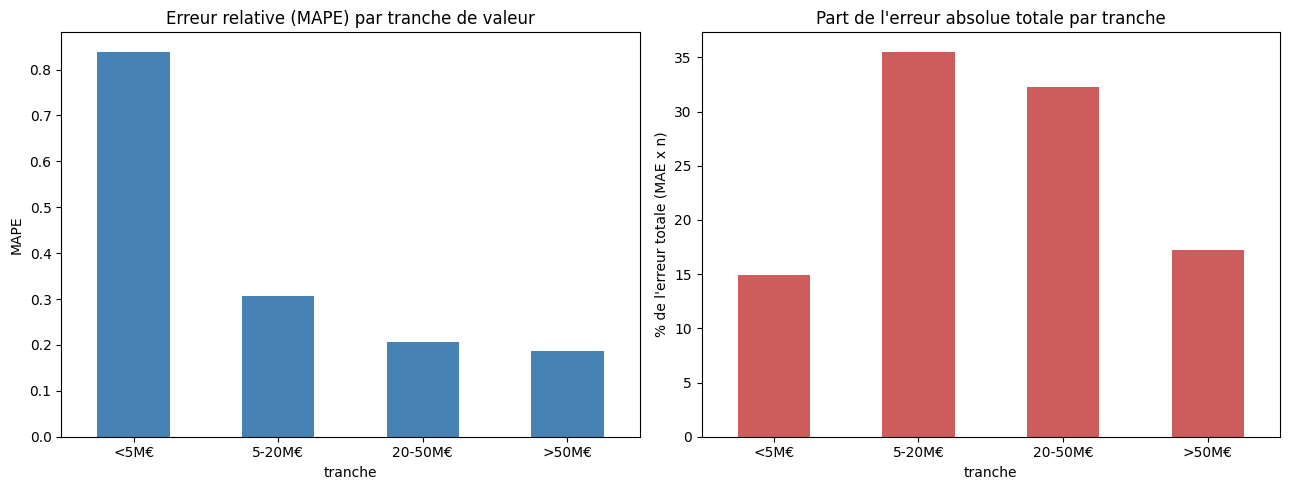

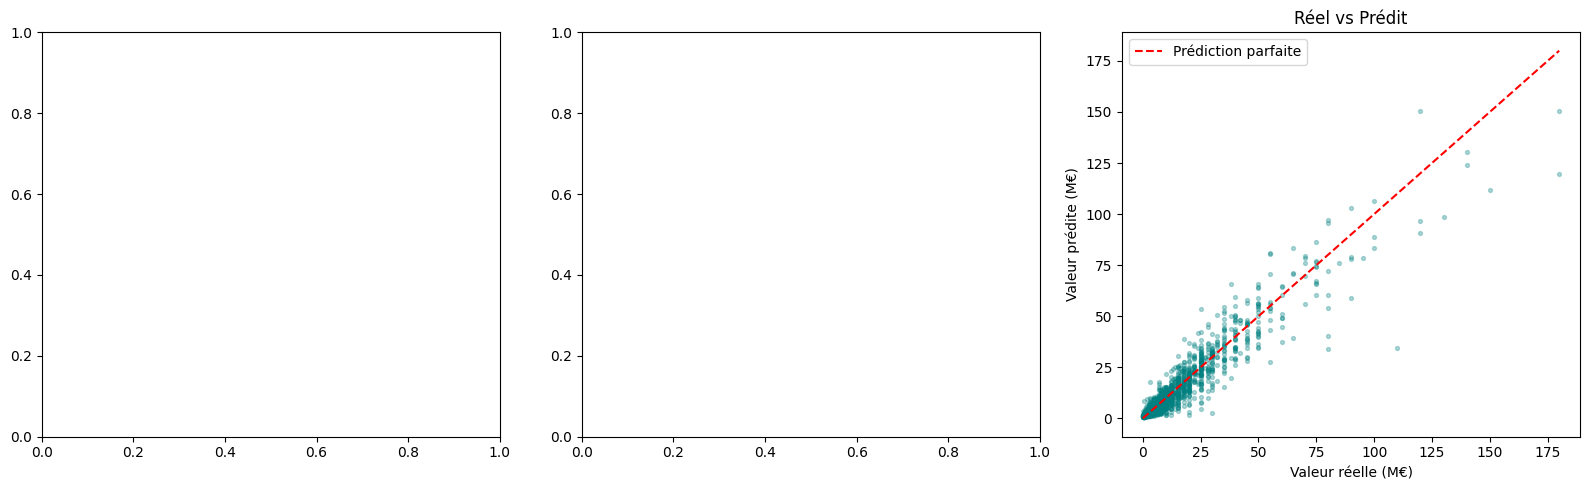

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

synthese_tranches["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Erreur relative (MAPE) par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)

synthese_tranches["% de l'erreur absolue totale"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale (MAE x n)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

#### B3.4 — Feature importance (CatBoost)

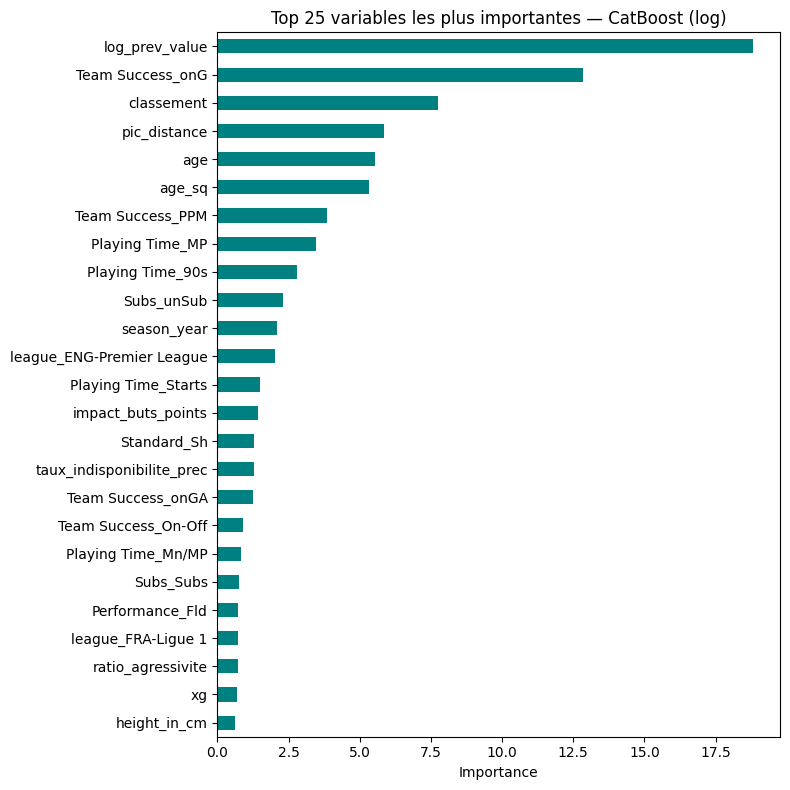

log_prev_value               18.819967
Team Success_onG             12.840974
classement                    7.741223
pic_distance                  5.833263
age                           5.543136
age_sq                        5.307174
Team Success_PPM              3.862769
Playing Time_MP               3.470134
Playing Time_90s              2.799989
Subs_unSub                    2.291537
season_year                   2.083146
league_ENG-Premier League     2.011016
Playing Time_Starts           1.505095
impact_buts_points            1.414822
Standard_Sh                   1.293377
taux_indisponibilite_prec     1.291768
Team Success_onGA             1.258600
Team Success_On-Off           0.894740
Playing Time_Mn/MP            0.841338
Subs_Subs                     0.770651
Performance_Fld               0.733068
league_FRA-Ligue 1            0.714325
ratio_agressivite             0.704997
xg                            0.680031
height_in_cm                  0.603833
dtype: float64


In [121]:
importances = pd.Series(
    modeles_tuned_log["CatBoost (log)"].get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(25).sort_values().plot(kind="barh", color="teal")
plt.title("Top 25 variables les plus importantes — CatBoost (log)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(25))

### B4 : Normalisation / Standardisation de la variable cible

**Ce qu'on teste :** une transformation de la valeur marchande différente de `log1p` améliore-t-elle les performances ?

**Ce qui varie ici :** la transformation de la cible.  
**Ce qui reste fixe :** pipeline Bloc A, mêmes hyperparamètres XGBoost, même test.

Pour isoler l'effet de la transformation seule, on utilise le **même XGBoost** sans retuner. Ensuite, on retune avec la meilleure transformation pour voir son plein potentiel.

| Transformation | Description 
|---|---
| Brute | Aucune 
| `log1p` | log(1+y) 
| `log10` | log₁₀(y) 
| `sqrt` | √y
| Yeo-Johnson | Transformation optimale MLE 
| MinMax [0,1] | Normalisation linéaire
| Rang centile | Quantile uniforme
| Rang normal | Quantile normal

#### B4.1 : Visualisation des distributions

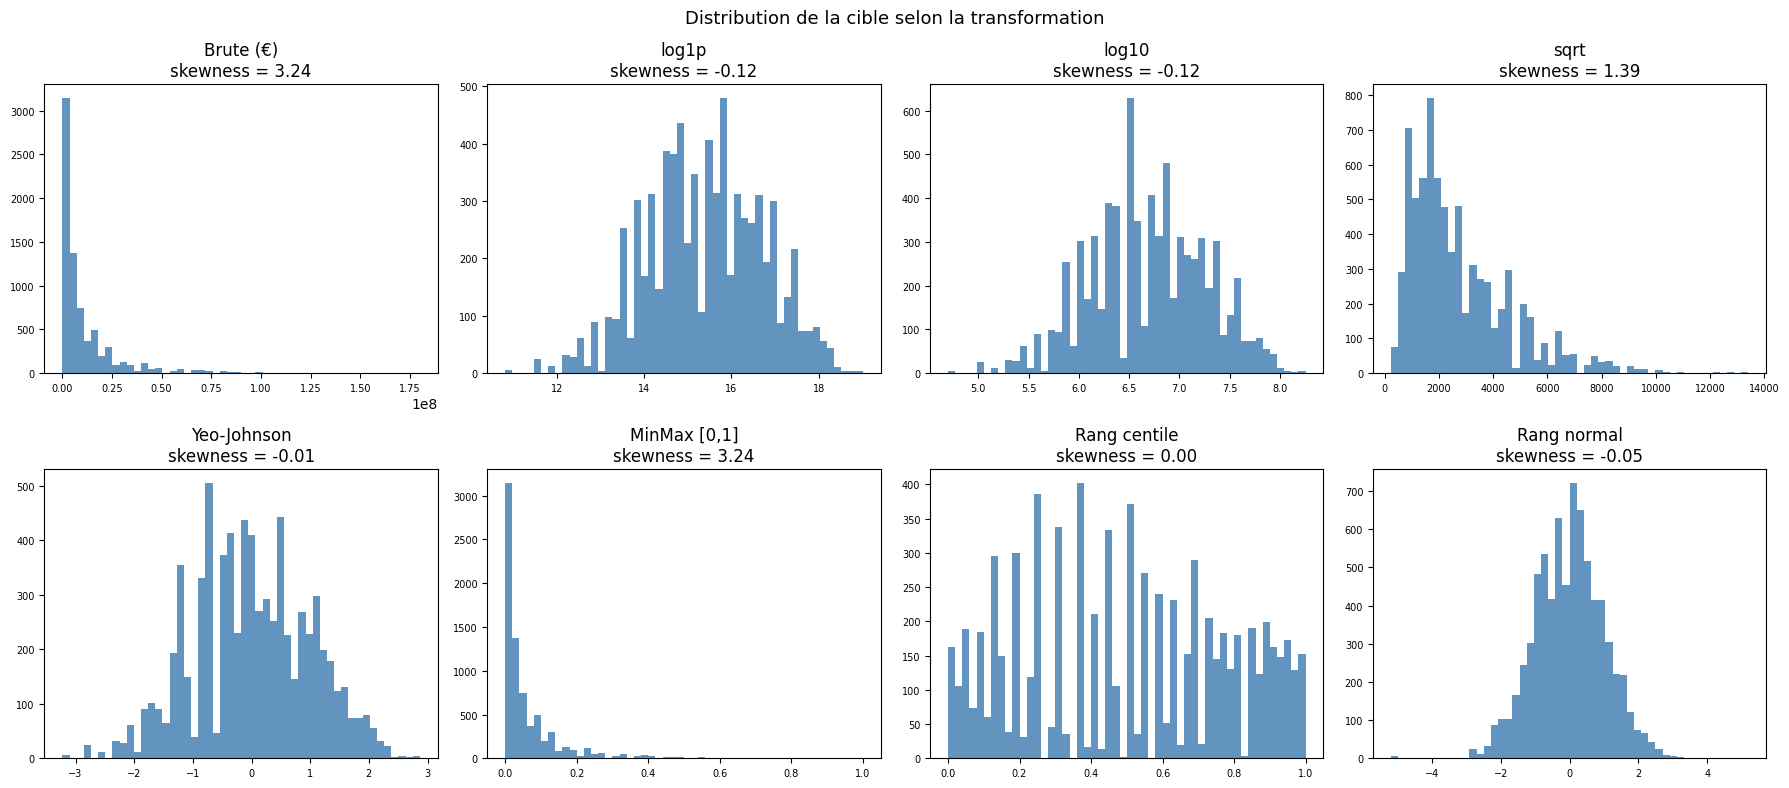

Statistiques de la cible brute :
count    7.404000e+03
mean     1.084476e+07
std      1.553714e+07
min      5.000000e+04
25%      2.000000e+06
50%      5.000000e+06
75%      1.400000e+07
max      1.800000e+08
Name: market_value_in_eur, dtype: float64
Skewness brute : 3.24
Skewness log1p : -0.12


In [122]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

transformations_viz = {
    "Brute (€)":           y_train,
    "log1p":               np.log1p(y_train),
    "log10":               np.log10(y_train),
    "sqrt":                np.sqrt(y_train),
    "Yeo-Johnson":         pd.Series(PowerTransformer(method="yeo-johnson")
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "MinMax [0,1]":        pd.Series(MinMaxScaler()
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "Rang centile":        pd.Series(QuantileTransformer(output_distribution="uniform",random_state=RANDOM_STATE)
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
    "Rang normal":         pd.Series(QuantileTransformer(output_distribution="normal",random_state=RANDOM_STATE)
                                     .fit_transform(y_train.values.reshape(-1,1)).flatten()),
}

for ax, (label, y_t) in zip(axes.flatten(), transformations_viz.items()):
    ax.hist(y_t, bins=50, color="steelblue", edgecolor="none", alpha=0.85)
    skew = float(pd.Series(y_t).skew())
    ax.set_title(f"{label}\nskewness = {skew:.2f}")
    ax.tick_params(labelsize=7)

plt.suptitle("Distribution de la cible selon la transformation", fontsize=13)
plt.tight_layout()
plt.show()

print("Statistiques de la cible brute :")
print(y_train.describe())
print(f"Skewness brute : {y_train.skew():.2f}")
print(f"Skewness log1p : {np.log1p(y_train).skew():.2f}")

#### B4.2 : Définition des transformations et fonctions inverses

Pour chaque transformation, on définit :
- `transform(y)` : passe les euros en espace de modélisation
- `inverse(y_pred)` : retransforme les prédictions en euros pour le calcul des métriques

In [123]:
# Fitter les transformateurs data-dependent sur le TRAIN uniquement
yj_transformer = PowerTransformer(method="yeo-johnson")
yj_transformer.fit(y_train.values.reshape(-1,1))

minmax_scaler = MinMaxScaler()
minmax_scaler.fit(y_train.values.reshape(-1,1))

quantile_unif = QuantileTransformer(output_distribution="uniform", random_state=RANDOM_STATE, n_quantiles=1000)
quantile_unif.fit(y_train.values.reshape(-1,1))

quantile_norm = QuantileTransformer(output_distribution="normal", random_state=RANDOM_STATE, n_quantiles=1000)
quantile_norm.fit(y_train.values.reshape(-1,1))

transformations = {
    "Brute": {
        "transform": lambda y: y,
        "inverse":   lambda y: np.clip(y, 0, None),
        "description": "Aucune transformation. MAE en euros bruts. Le modèle essaie de minimiser les erreurs absolues en €, donc surpondère les stars.",
    },
    "log1p (baseline)": {
        "transform": lambda y: np.log1p(y),
        "inverse":   lambda y: np.expm1(y),
        "description": "log(1+y) — transformation de référence. Compresse l'échelle, donne le même poids à chaque ordre de grandeur.",
    },
    "log10": {
        "transform": lambda y: np.log10(np.clip(y, 1, None)),
        "inverse":   lambda y: np.power(10, y),
        "description": "log10(y) — même effet que log1p mais l'espace est plus lisible : 6 = 1M€, 7 = 10M€, 7.7 = 50M€.",
    },
    "sqrt": {
        "transform": lambda y: np.sqrt(y),
        "inverse":   lambda y: np.square(np.clip(y, 0, None)),
        "description": "Racine carrée — compression plus douce que le log. Bon compromis si la distribution est modérément asymétrique.",
    },
    "Yeo-Johnson": {
        "transform": lambda y: yj_transformer.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(yj_transformer.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transformation de Box-Cox généralisée (fonctionne avec les zéros). Trouve automatiquement la transformation optimale par maximum de vraisemblance.",
    },
    "MinMax [0,1]": {
        "transform": lambda y: minmax_scaler.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(minmax_scaler.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Normalisation dans [0,1]. Sensible aux outliers (1 joueur à 200M€ écrase tout). Métriques en [0,1] très lisibles mais peu robustes.",
    },
    "Rang centile [0,1]": {
        "transform": lambda y: quantile_unif.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(quantile_unif.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transforme en rangs uniformes [0,1]. Robuste aux outliers, distribution parfaitement uniforme. Problème : perd la notion d'amplitude entre valeurs.",
    },
    "Rang normal": {
        "transform": lambda y: quantile_norm.transform(y.values.reshape(-1,1)).flatten(),
        "inverse":   lambda y: np.clip(quantile_norm.inverse_transform(y.reshape(-1,1)).flatten(), 0, None),
        "description": "Transforme en distribution normale centrée réduite. Bien adapté aux modèles supposant la normalité des résidus.",
    },
}

print(f"{len(transformations)} transformations définies.")

8 transformations définies.


#### B4.3 : Entraînement et évaluation pour chaque transformation

In [124]:
def evaluer_complet(label, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    rmse_log = np.sqrt(mean_squared_error(np.log1p(y_true),
                                           np.log1p(np.clip(y_pred,0,None))))
    return {"Transformation": label, "MAE": mae, "RMSE": rmse,
            "MAPE": mape, "R²": r2, "RMSE_log": rmse_log}

# Modèle XGBoost fixe (hyperparamètres du modèle initial) — on ne retune pas pour que la
# comparaison soit équitable (on ne veut pas confondre l'effet de la
# transformation avec l'effet du tuning)
def make_xgb():
    return XGBRegressor(
        n_estimators=1500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.01, reg_lambda=1.5,
        tree_method="hist", enable_categorical=True,
        objective="reg:squarederror",
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )

resultats = []
predictions_test = {}

for label, transfo in transformations.items():
    print(f"\n--- {label} ---")
    print(f"  {transfo['description'][:80]}...")

    try:
        y_tr_t  = transfo["transform"](y_train)
        y_val_t = transfo["transform"](y_val)
        y_te_t  = transfo["transform"](y_test)  # uniquement pour info

        # Poids adaptés : toujours sur-pondérer les petites valeurs EN EUROS
        # (indépendamment de la transformation utilisée pour la cible)
        sw = sample_weights_train.values

        xgb = make_xgb()
        xgb.fit(X_train, y_tr_t, sample_weight=sw)

        # Prédictions sur le test → retransformer en euros
        preds_t = xgb.predict(X_test)
        preds_eur = transfo["inverse"](preds_t if isinstance(preds_t, np.ndarray) else np.array(preds_t))

        res = evaluer_complet(label, y_test.values, preds_eur)
        resultats.append(res)
        predictions_test[label] = preds_eur

        print(f"  → MAPE: {res['MAPE']:.2%} | R²: {res['R²']:.4f} | "
              f"MAE: {res['MAE']:>10,.0f}€ | RMSE_log: {res['RMSE_log']:.4f}")

    except Exception as e:
        print(f"  Erreur : {e}")


--- Brute ---
  Aucune transformation. MAE en euros bruts. Le modèle essaie de minimiser les err...
  → MAPE: 69.02% | R²: 0.9003 | MAE:  3,357,624€ | RMSE_log: 1.4041

--- log1p (baseline) ---
  log(1+y) — transformation de référence. Compresse l'échelle, donne le même poids...
  → MAPE: 41.50% | R²: 0.8716 | MAE:  3,332,405€ | RMSE_log: 0.5397

--- log10 ---
  log10(y) — même effet que log1p mais l'espace est plus lisible : 6 = 1M€, 7 = 10...
  → MAPE: 41.00% | R²: 0.8738 | MAE:  3,341,811€ | RMSE_log: 0.5376

--- sqrt ---
  Racine carrée — compression plus douce que le log. Bon compromis si la distribut...
  → MAPE: 48.96% | R²: 0.8922 | MAE:  3,203,238€ | RMSE_log: 0.5444

--- Yeo-Johnson ---
  Transformation de Box-Cox généralisée (fonctionne avec les zéros). Trouve automa...
  → MAPE: 41.65% | R²: 0.8745 | MAE:  3,305,372€ | RMSE_log: 0.5366

--- MinMax [0,1] ---
  Normalisation dans [0,1]. Sensible aux outliers (1 joueur à 200M€ écrase tout). ...
  → MAPE: 64.18% | R²: 0.9002 |

#### B4.4 : Tableau comparatif par MAPE croissant

=== CLASSEMENT PAR MAPE (↓ meilleur) ===
                               MAE            RMSE    MAPE      R² RMSE_log
Transformation                                                             
Rang normal            3,234,539 €     5,968,563 €  40.59%  0.8933   0.5408
log10                  3,341,811 €     6,491,451 €  41.00%  0.8738   0.5376
log1p (baseline)       3,332,405 €     6,545,917 €  41.50%  0.8716   0.5397
Yeo-Johnson            3,305,372 €     6,472,080 €  41.65%  0.8745   0.5366
Rang centile [0,1]     4,564,733 €    12,764,240 €  48.56%  0.5119   0.5727
sqrt                   3,203,238 €     5,998,564 €  48.96%  0.8922   0.5444
MinMax [0,1]           3,331,845 €     5,771,599 €  64.18%  0.9002   1.2522
Brute                  3,357,624 €     5,768,675 €  69.02%  0.9003   1.4041


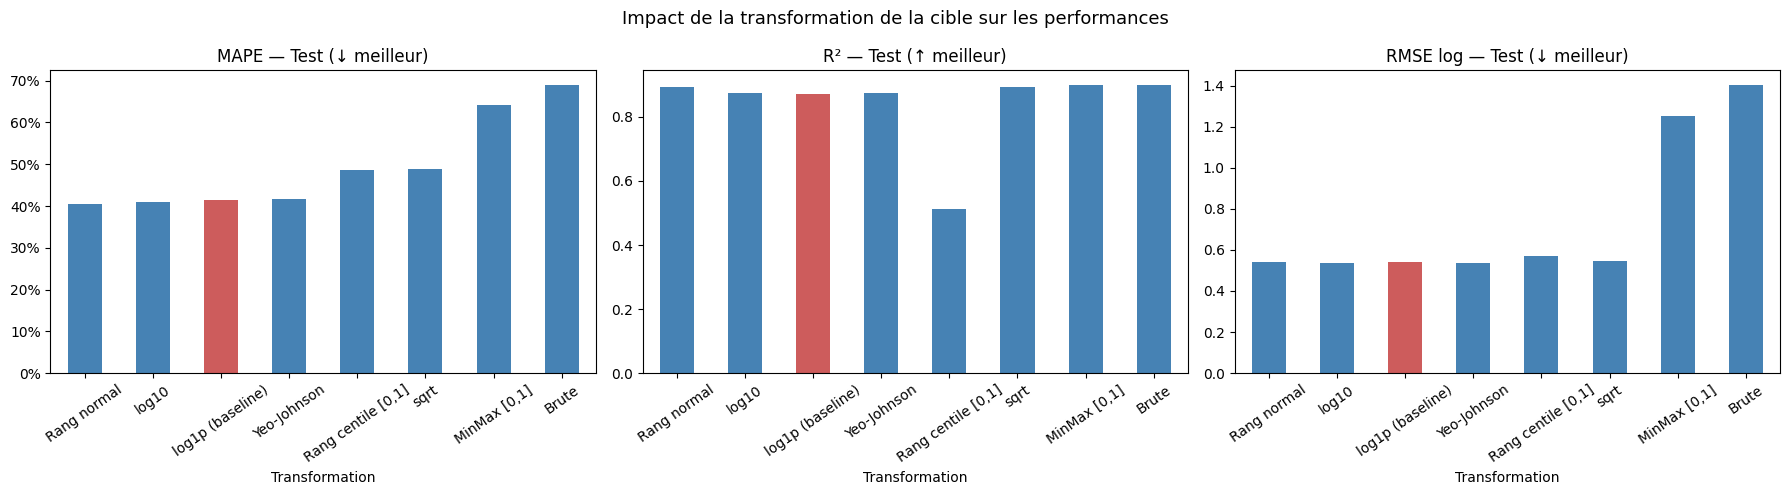

In [125]:
df_res = pd.DataFrame(resultats).set_index("Transformation")
df_res_sorted = df_res.sort_values("MAPE")

print("=== CLASSEMENT PAR MAPE (↓ meilleur) ===")
df_display = df_res_sorted.copy()
df_display["MAE"]      = df_display["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_display["RMSE"]     = df_display["RMSE"].apply(lambda x: f"{x:>12,.0f} €")
df_display["MAPE"]     = df_display["MAPE"].apply(lambda x: f"{x:.2%}")
df_display["R²"]       = df_display["R²"].apply(lambda x: f"{x:.4f}")
df_display["RMSE_log"] = df_display["RMSE_log"].apply(lambda x: f"{x:.4f}")
print(df_display.to_string())

# Barplot des métriques clés
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["indianred" if "baseline" in l else "steelblue" for l in df_res_sorted.index]

df_res_sorted["MAPE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="none")
axes[0].set_title("MAPE — Test (↓ meilleur)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=35)

df_res_sorted["R²"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="none")
axes[1].set_title("R² — Test (↑ meilleur)")
axes[1].tick_params(axis="x", rotation=35)

df_res_sorted["RMSE_log"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="none")
axes[2].set_title("RMSE log — Test (↓ meilleur)")
axes[2].tick_params(axis="x", rotation=35)

plt.suptitle("Impact de la transformation de la cible sur les performances", fontsize=13)
plt.tight_layout()
plt.show()

#### B4.5 : Analyse par tranche de valeur

=== MAPE PAR TRANCHE SELON LA TRANSFORMATION ===
Transformation                     <5M€   5-20M€  20-50M€    >50M€
-----------------------------------------------------------------
Brute                           117.6%    30.5%    20.2%    18.5%
log1p (baseline)                 57.8%    30.9%    21.0%    21.2%
log10                            56.4%    31.3%    21.1%    21.7%
sqrt                             75.0%    30.2%    19.7%    19.2%
Yeo-Johnson                      58.2%    31.2%    20.2%    21.6%
MinMax [0,1]                    107.6%    30.0%    20.4%    18.1%
Rang centile [0,1]               68.6%    30.2%    26.6%    58.1%
Rang normal                      55.2%    32.5%    20.2%    18.7%


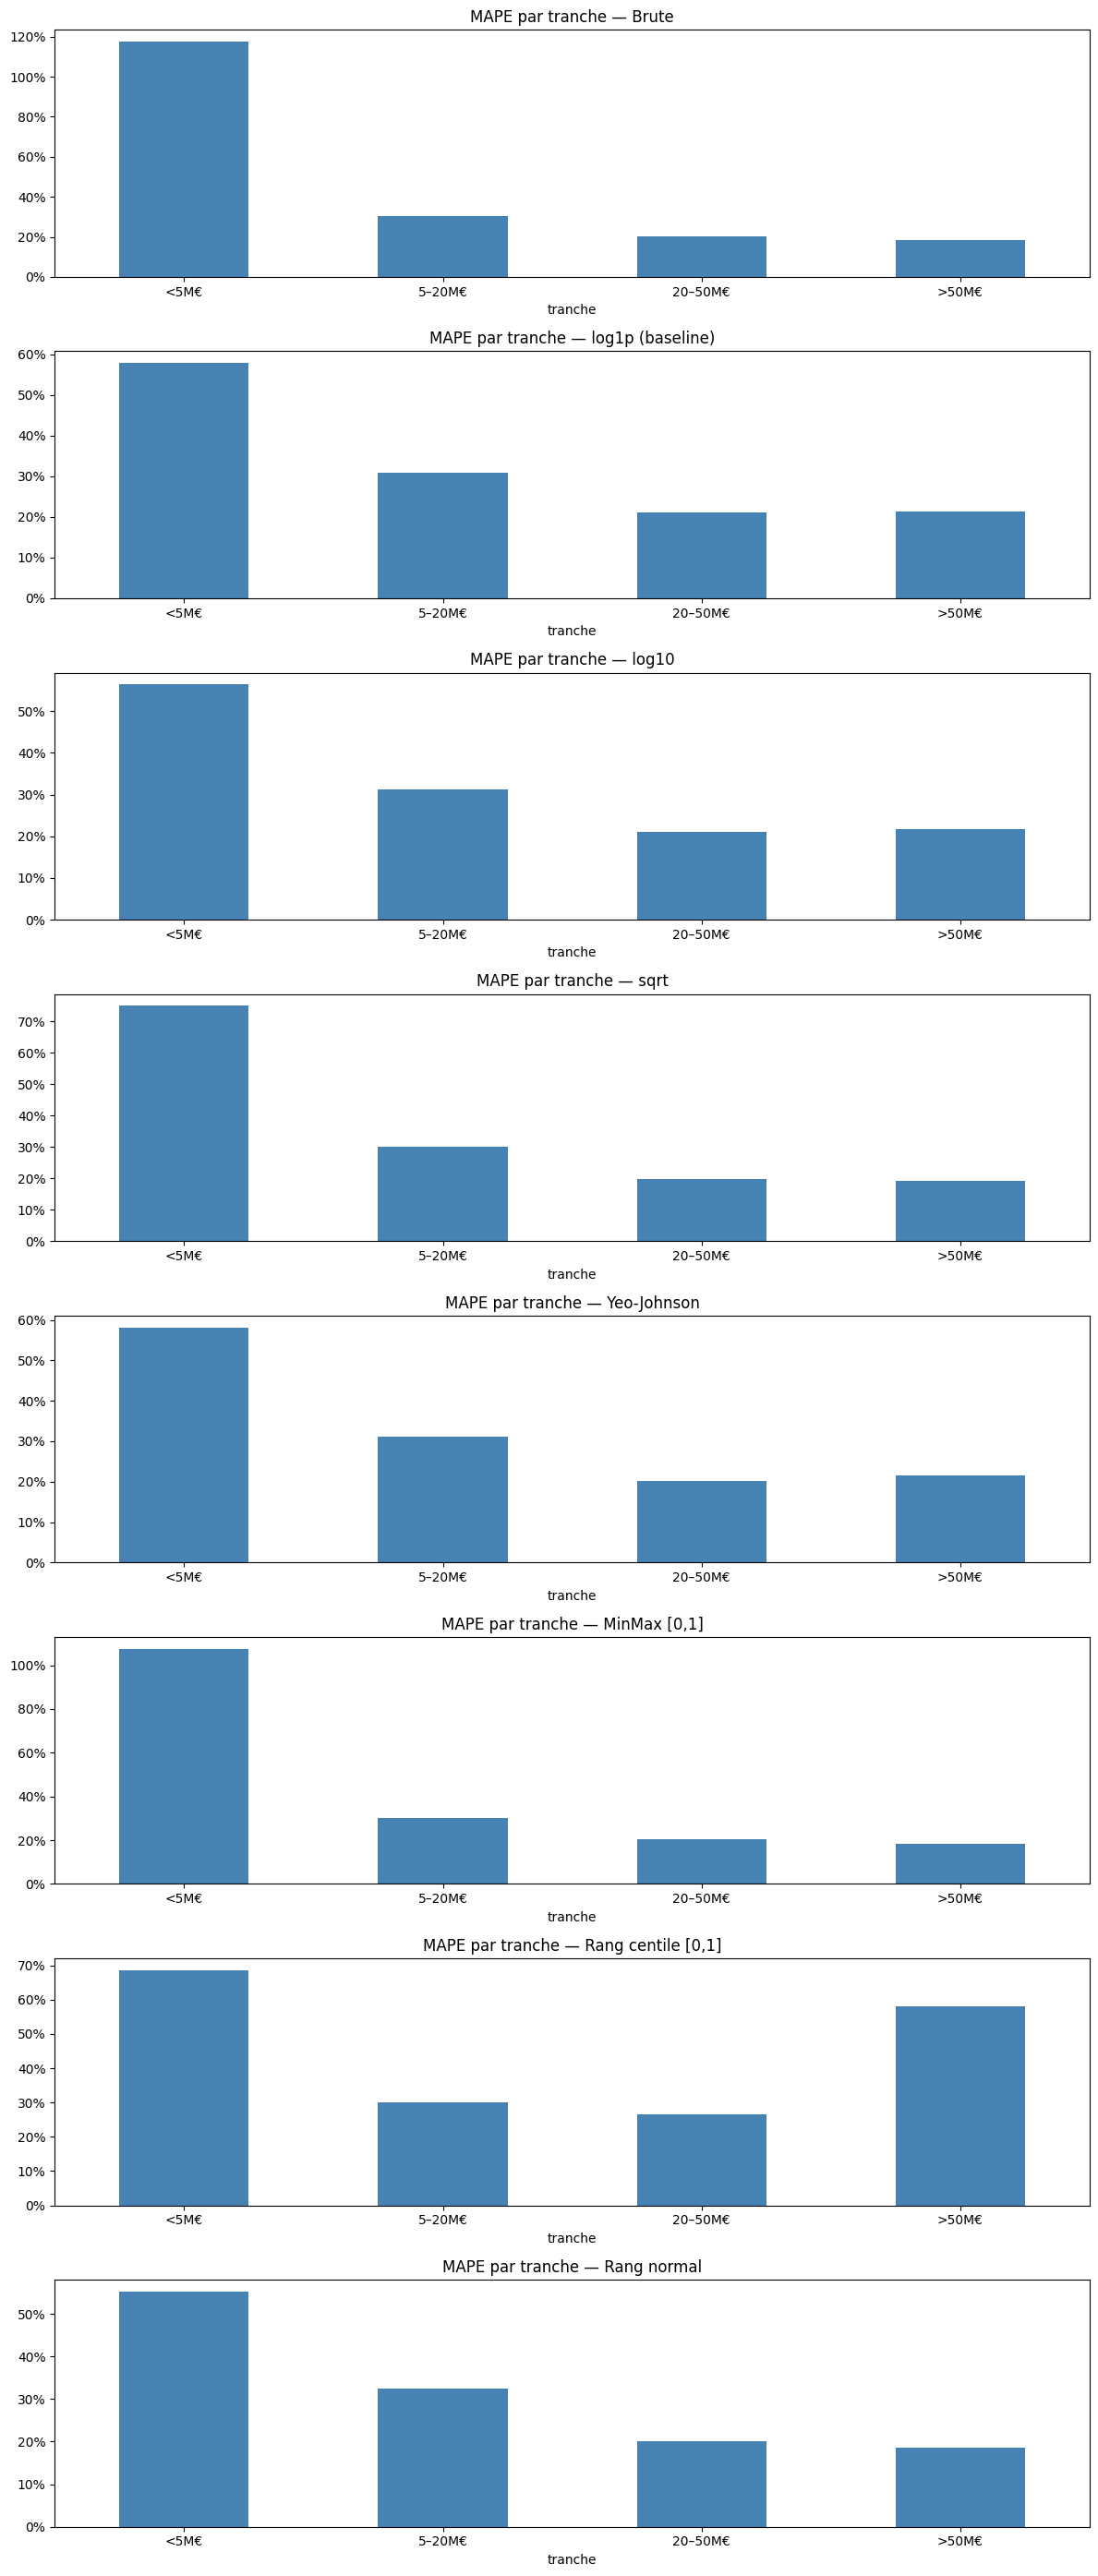

In [126]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€","5–20M€","20–50M€",">50M€"]

fig, axes = plt.subplots(len(predictions_test), 1, figsize=(12, 3.5*len(predictions_test)))
if len(predictions_test) == 1: axes = [axes]

print("=== MAPE PAR TRANCHE SELON LA TRANSFORMATION ===")
print(f"{'Transformation':30s} {'<5M€':>8} {'5-20M€':>8} {'20-50M€':>8} {'>50M€':>8}")
print("-"*65)

for ax, (label, preds) in zip(axes, predictions_test.items()):
    df_err = pd.DataFrame({"y": y_test.values, "pred": preds})
    df_err["err_pct"] = (df_err["y"]-df_err["pred"]).abs()/df_err["y"]
    df_err["tranche"] = pd.cut(df_err["y"], bins=tranches, labels=labels_tranches)

    mapes = df_err.groupby("tranche", observed=True)["err_pct"].mean()
    print(f"{label:30s} {mapes.get('<5M€',np.nan):>7.1%} {mapes.get('5–20M€',np.nan):>8.1%} "
          f"{mapes.get('20–50M€',np.nan):>8.1%} {mapes.get('>50M€',np.nan):>8.1%}")

    mapes.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(f"MAPE par tranche — {label}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

#### B4.6 : Tuning et Stacking OOF avec la meilleure transformation

On identifie la transformation qui minimise le MAPE, puis on retune XGBoost + LightGBM + CatBoost avec cette transformation et on construit le Stacking OOF final pour voir son plein potentiel.

In [127]:
# On identifie la meilleure transformation selon le MAPE
meilleure_transfo = df_res["MAPE"].idxmin()
print(f"Meilleure transformation selon MAPE : {meilleure_transfo}")
print(f"MAPE : {df_res.loc[meilleure_transfo, 'MAPE']:.2%}")
print(f"R²   : {df_res.loc[meilleure_transfo, 'R²']:.4f}")

# Si la meilleure n'est pas log1p, on tune XGB+LGBM+CAT + stacking OOF
# avec la meilleure transformation pour voir le plein potentiel
transfo_best = transformations[meilleure_transfo]
y_tr_best  = pd.Series(transfo_best["transform"](y_train), index=y_train.index)
y_val_best = pd.Series(transfo_best["transform"](y_val),   index=y_val.index)
y_te_best  = pd.Series(transfo_best["transform"](y_test),  index=y_test.index)

print(f"\nDistribution de la cible transformée ({meilleure_transfo}) :")
print(y_tr_best.describe())
print(f"Skewness : {y_tr_best.skew():.3f}")

Meilleure transformation selon MAPE : Rang normal
MAPE : 40.59%
R²   : 0.8933

Distribution de la cible transformée (Rang normal) :
count    7404.000000
mean       -0.000593
std         1.007966
min        -5.199338
25%        -0.653377
50%         0.027604
75%         0.691121
max         5.199338
dtype: float64
Skewness : -0.045


In [128]:
def objective_xgb_best(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":"hist","enable_categorical":True,"objective":"reg:squarederror",
        "random_state":RANDOM_STATE,"n_jobs":-1,"verbosity":0,
    }
    m = XGBRegressor(**params)
    m.fit(X_train, y_tr_best, sample_weight=sample_weights_train)
    preds_t   = m.predict(X_val)
    preds_eur = transfo_best["inverse"](preds_t)
    # Optimiser RMSE log (≈ MAPE) dans l'espace euros pour cohérence
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning XGBoost avec transformation '{meilleure_transfo}' ---")
study_xgb_best = optuna.create_study(direction="minimize",
                                      sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb_best.optimize(objective_xgb_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_xgb_best.best_value:.4f}")
print(f"Params : {study_xgb_best.best_params}")

--- Tuning XGBoost avec transformation 'Rang normal' ---


Best trial: 14. Best value: 0.533715: 100%|██████████| 30/30 [14:41<00:00, 29.38s/it]

Meilleur RMSE log : 0.5337
Params : {'n_estimators': 2000, 'max_depth': 9, 'learning_rate': 0.01697330656247076, 'subsample': 0.7689963261475954, 'colsample_bytree': 0.8840745424274534, 'min_child_weight': 0.6069145594049878, 'reg_alpha': 0.0034512772467425405, 'reg_lambda': 0.00032648372154189033}


In [129]:
def objective_lgbm_best(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":RANDOM_STATE,"n_jobs":-1,"verbose":-1,
    }
    m = LGBMRegressor(**params)
    m.fit(X_train, y_tr_best, sample_weight=sample_weights_train)
    preds_eur = transfo_best["inverse"](m.predict(X_val))
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning LightGBM ---")
study_lgbm_best = optuna.create_study(direction="minimize",
                                       sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm_best.optimize(objective_lgbm_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_lgbm_best.best_value:.4f}")

def objective_cat_best(trial):
    params = {
        "iterations":            trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                 trial.suggest_int("depth", 4, 8),
        "learning_rate":         trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":             trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":"Bernoulli","random_state":RANDOM_STATE,
        "early_stopping_rounds":50,"verbose":0,
    }
    m = CatBoostRegressor(**params)
    m.fit(X_train, y_tr_best, eval_set=(X_val, y_val_best),
          sample_weight=sample_weights_train, verbose=False)
    preds_eur = transfo_best["inverse"](m.predict(X_val))
    return np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(np.clip(preds_eur,0,None))))

print(f"--- Tuning CatBoost ---")
study_cat_best = optuna.create_study(direction="minimize",
                                      sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat_best.optimize(objective_cat_best, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Meilleur RMSE log : {study_cat_best.best_value:.4f}")

--- Tuning LightGBM ---


Best trial: 8. Best value: 0.53893: 100%|██████████| 30/30 [05:51<00:00, 11.72s/it]


Meilleur RMSE log : 0.5389
--- Tuning CatBoost ---


Best trial: 20. Best value: 0.540445: 100%|██████████| 30/30 [08:13<00:00, 16.45s/it]

Meilleur RMSE log : 0.5404


In [130]:
# Stacking OOF avec la meilleure transformation
xgb_f = XGBRegressor(**study_xgb_best.best_params, tree_method="hist",
                      enable_categorical=True, objective="reg:squarederror",
                      random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
lgbm_f = LGBMRegressor(**study_lgbm_best.best_params,
                         random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
cat_f  = CatBoostRegressor(**study_cat_best.best_params, bootstrap_type="Bernoulli",
                             random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0)

modeles_f = {"XGBoost": xgb_f, "LightGBM": lgbm_f, "CatBoost": cat_f}
sw = sample_weights_train.values

# OOF
print("Génération OOF...")
oof = {}
for nom, m in modeles_f.items():
    oof[nom] = cross_val_predict(m, X_train, y_tr_best, cv=5, n_jobs=-1)
    preds_eur_oof = transfo_best["inverse"](oof[nom])
    mape_oof = mean_absolute_percentage_error(y_train, preds_eur_oof)
    print(f"  {nom}: OOF MAPE = {mape_oof:.2%}")

X_meta_tr = pd.DataFrame(oof)

# Ré-entraînement
for nom, m in modeles_f.items():
    if isinstance(m, CatBoostRegressor):
        m.fit(X_train, y_tr_best, eval_set=(X_val, y_val_best),
              sample_weight=sw, verbose=False)
    else:
        m.fit(X_train, y_tr_best, sample_weight=sw)

X_meta_val = pd.DataFrame({n: m.predict(X_val)  for n,m in modeles_f.items()})
X_meta_te  = pd.DataFrame({n: m.predict(X_test) for n,m in modeles_f.items()})

meta = LinearRegression(positive=True)
meta.fit(X_meta_tr, y_tr_best)
print(f"Poids méta : { {n:round(w,3) for n,w in zip(modeles_f.keys(),meta.coef_)} }")

pred_test_tuned_eur = transfo_best["inverse"](meta.predict(X_meta_te))

res_tuned = evaluer_complet(f"Tuné + Stack ({meilleure_transfo})", y_test.values, pred_test_tuned_eur)
print(f"\n=== RÉSULTAT FINAL (tuné, stacking OOF) ===")
print(f"  MAPE     : {res_tuned['MAPE']:.2%}")
print(f"  R²       : {res_tuned['R²']:.4f}")
print(f"  MAE      : {res_tuned['MAE']:>12,.0f} €")
print(f"  RMSE_log : {res_tuned['RMSE_log']:.4f}")
resultats.append(res_tuned)

Génération OOF...
  XGBoost: OOF MAPE = 43.91%
  LightGBM: OOF MAPE = 43.97%
  CatBoost: OOF MAPE = 42.55%
Poids méta : {'XGBoost': np.float64(0.222), 'LightGBM': np.float64(0.133), 'CatBoost': np.float64(0.666)}

=== RÉSULTAT FINAL (tuné, stacking OOF) ===
  MAPE     : 39.44%
  R²       : 0.8925
  MAE      :    3,266,200 €
  RMSE_log : 0.5302


#### B4.7 : Résultat final

In [131]:
# Référence (Stacking OOF, log1p, tuné)
v4_ref = {"Transformation": "log1p — modèle référence (tuné)",
           "MAPE": 0.3857, "R²": 0.880, "MAE": 3_340_118,
           "RMSE": None, "RMSE_log": 0.552}

df_final = pd.DataFrame(resultats + [v4_ref]).set_index("Transformation")
df_final = df_final.sort_values("MAPE")

print("=== CLASSEMENT FINAL ===")
for col in ["MAPE","R²","RMSE_log"]:
    df_final[col] = df_final[col].apply(lambda x:
        f"{x:.2%}" if col=="MAPE" else f"{x:.4f}" if x is not None else "—")
print(df_final[["MAPE","R²","RMSE_log"]].to_string())

=== CLASSEMENT FINAL ===
                                   MAPE      R² RMSE_log
Transformation                                          
log1p — modèle référence (tuné)  38.57%  0.8800   0.5520
Tuné + Stack (Rang normal)       39.44%  0.8925   0.5302
Rang normal                      40.59%  0.8933   0.5408
log10                            41.00%  0.8738   0.5376
log1p (baseline)                 41.50%  0.8716   0.5397
Yeo-Johnson                      41.65%  0.8745   0.5366
Rang centile [0,1]               48.56%  0.5119   0.5727
sqrt                             48.96%  0.8922   0.5444
MinMax [0,1]                     64.18%  0.9002   1.2522
Brute                            69.02%  0.9003   1.4041


### B5 : Retrait des valeurs extrêmes

**Ce qu'on teste :** retirer les valeurs marchandes extrêmes du train améliore-t-il les performances ?

**Ce qui varie ici :** le filtrage du train (seuil IQR).  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test intouché.

**Hypothèse :** les joueurs > ~80M€ sont valorisés par des facteurs non capturés dans les stats (réputation médiatique, rareté, contexte de mercato). Leur présence dans le train peut biaiser l'apprentissage.

#### B5.1 : Chargement et identification des outliers

In [132]:
df_train_initial = pd.read_csv("../data_finale/featuring/train_featured.csv")
df_val_initial   = pd.read_csv("../data_finale/featuring/val_featured.csv")
df_test_initial  = pd.read_csv("../data_finale/featuring/test_featured.csv")

# Calcul des quartiles et de l'IQR uniquement sur le TRAIN
Q1 = df_train_initial['market_value_in_eur'].quantile(0.25)
Q3 = df_train_initial['market_value_in_eur'].quantile(0.75)
IQR = Q3 - Q1

# Définition du seuil supérieur uniquement
# (Pas besoin de seuil inférieur puisqu'on garde tout ce qui est petit)
seuil_superieur = Q3 + 1.5 * IQR

# Filtrage : on ne garde que ce qui est INFÉRIEUR ou ÉGAL au seuil maximum
df_train = df_train_initial[df_train_initial['market_value_in_eur'] <= seuil_superieur]
df_val   = df_val_initial[df_val_initial['market_value_in_eur'] <= seuil_superieur]
df_test  = df_test_initial[df_test_initial['market_value_in_eur'] <= seuil_superieur]

# Vérification du nombre de lignes supprimées
print(f"Seuil max appliqué : {seuil_superieur:.2f}")
print(f"Lignes supprimées dans Train : {len(df_train_initial) - len(df_train)}")
print(f"Lignes supprimées dans Val   : {len(df_val_initial) - len(df_val)}")
print(f"Lignes supprimées dans Test  : {len(df_test_initial) - len(df_test)}")

colonne_cible  = "market_value_in_eur"
colonne_joueur = "player"
colonne_team   = "team"
colonne_nation = "nation"

df_train = df_train.dropna(subset=[colonne_cible])
df_val   = df_val.dropna(subset=[colonne_cible])
df_test  = df_test.dropna(subset=[colonne_cible])

Seuil max appliqué : 32000000.00
Lignes supprimées dans Train : 570
Lignes supprimées dans Val   : 224
Lignes supprimées dans Test  : 172


#### B5.2 : Feature Engineering à recalculer

In [133]:
# Valeur marchande de la saison précédente

# On crée une base d'historique propre et triée par temps (sans toucher à tes df de split)
df_history = pd.concat([df_train, df_val, df_test], axis=0)
df_history = df_history.sort_values(["player", "season_year"])

# On calcule le shift sur cet historique de référence
df_history["log_prev_value"] = np.log1p(
    df_history.groupby("player")["market_value_in_eur"].shift(1)
)

df_train = df_history[df_history["season_year"].isin([2020, 2021, 2022])].copy()
df_val   = df_history[df_history["season_year"] == 2023].copy()
df_test  = df_history[df_history["season_year"] == 2024].copy()

In [134]:
# Imputation des nouvelles variables (Ligue × Position)
# Les statistiques sont apprises uniquement sur le train


# On liste toutes tes colonnes qui commencent par 'league_'
league_cols = [col for col in df_train.columns if col.startswith('league_')]

def extraire_nom_ligue(df):
    df_temp = df.copy()
    # Si le joueur a un '1' dans une colonne league, on extrait le nom, sinon 'Other'
    df_temp['league_name'] = df_temp[league_cols].idxmax(axis=1).where(df_temp[league_cols].max(axis=1) == 1, 'league_Other')
    return df_temp

# On crée des versions temporaires avec la colonne 'league_name'
df_train_temp = extraire_nom_ligue(df_train)


# log_prev_value par Ligue et position
prev_pos_league = (
    df_train_temp
    .groupby(["league_name", "position"])["log_prev_value"]
    .median()
)

# Médiane par position simple (en secours)
prev_pos_backup = (
    df_train_temp
    .groupby("position")["log_prev_value"]
    .median()
)

prev_global = df_train_temp["log_prev_value"].median()




def impute_features(df):
    # On génère la colonne temporaire pour mapper les données
    df_with_league = extraire_nom_ligue(df)
    
    # Sauvegarde de l'index d'origine pour la conversion en Série
    original_index = df_with_league.index    

    mapped_prev_value = (
        df_with_league.set_index(["league_name", "position"])
        .index.map(prev_pos_league)
        .to_series(index=original_index)
    )
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(mapped_prev_value)

    # Secours 1 : Par Position simple
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        df_with_league["position"].map(prev_pos_backup)
    )

    # Secours 2 : Médiane globale
    df_with_league["log_prev_value"] = df_with_league["log_prev_value"].fillna(
        prev_global
    )

    # On supprime la colonne temporaire avant de renvoyer le DataFrame propre
    return df_with_league.drop(columns=['league_name'])


df_train = impute_features(df_train)
df_val   = impute_features(df_val)
df_test  = impute_features(df_test)

#### B5.3 : Préparation des jeux X / y

In [135]:
cols_a_supprimer = [
    colonne_cible, colonne_joueur, colonne_team, colonne_nation,
    "position"
]
# On supprime uniquement les colonnes qui existent réellement
cols_a_supprimer = [c for c in cols_a_supprimer if c in df_train.columns]
colonnes_nor = [c for c in df_train.columns if c.endswith("_nor")]

df_train = df_train.drop(columns=colonnes_nor, errors="ignore")
df_val   = df_val.drop(columns=colonnes_nor, errors="ignore")
df_test  = df_test.drop(columns=colonnes_nor, errors="ignore")

X_train = df_train.drop(columns=cols_a_supprimer)
y_train = df_train[colonne_cible]

X_val   = df_val.drop(columns=cols_a_supprimer)
y_val   = df_val[colonne_cible]

X_test  = df_test.drop(columns=cols_a_supprimer)
y_test  = df_test[colonne_cible]

# Cibles log
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# Poids d'entraînement : sur-pondère les petites valeurs pour améliorer le MAPE
# w_i = 1 / log1p(y_i)  → les joueurs à faible valeur pèsent autant que les stars
sample_weights_train = 1 / np.log1p(y_train)
sample_weights_train = sample_weights_train / sample_weights_train.mean()

print(f"X_train : {X_train.shape} | X_val : {X_val.shape} | X_test : {X_test.shape}")

X_train : (6834, 145) | X_val : (2207, 145) | X_test : (1579, 145)


#### B5.4 : Tuning des hyperparamètres

In [136]:
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "tree_method":       "hist",
        "enable_categorical": True,
        "objective":         "reg:squarederror",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbosity":         0,
    }
    
    model = XGBRegressor(**params)
    
    # Entraînement classique sur la cible log
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # On fait la prédiction en log
    preds_log = model.predict(X_val)
    
    # On calcule le RMSE directement sur les logs (y_val_log) pour la stabilité d'Optuna
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

print("--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---")
study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)

# Pour afficher un vrai MAPE business à la fin (calculé hors de la boucle) :
best_model = XGBRegressor(**study_xgb.best_params, tree_method="hist", enable_categorical=True, random_state=RANDOM_STATE)
best_model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds = np.expm1(best_model.predict(X_val))
final_mape = mean_absolute_percentage_error(y_val, final_preds)

print(f"Meilleur RMSE log val : {study_xgb.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape:.4f}")
print(f"Params : {study_xgb.best_params}")

--- Tuning XGBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 23. Best value: 0.55282: 100%|██████████| 30/30 [12:02<00:00, 24.07s/it] 


Meilleur RMSE log val : 0.5528
MAPE réel correspondant : 0.4365
Params : {'n_estimators': 2000, 'max_depth': 8, 'learning_rate': 0.006665048825397166, 'subsample': 0.6336280788427932, 'colsample_bytree': 0.6915174337340527, 'min_child_weight': 6.194194604506766, 'reg_alpha': 0.038073120305824014, 'reg_lambda': 0.005644186927849634}


In [137]:
def objective_lgbm(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 500, 5000, step=250),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
        "max_depth":         trial.suggest_int("max_depth", 3, 15),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        "verbose":           -1,
    }
    model = LGBMRegressor(**params)
    model.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    
    # MODIFICATION : On reste en log pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On renvoie le RMSE calculé sur les logs
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes des prints pour l'affichage
print("--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---")
study_lgbm = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(objective_lgbm, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_lgbm = LGBMRegressor(**study_lgbm.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
best_lgbm.fit(X_train, y_train_log, sample_weight=sample_weights_train)
final_preds_lgbm = np.expm1(best_lgbm.predict(X_val))
final_mape_lgbm = mean_absolute_percentage_error(y_val, final_preds_lgbm)

print(f"Meilleur RMSE log val : {study_lgbm.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_lgbm:.4f}")
print(f"Params : {study_lgbm.best_params}")

--- Tuning LightGBM (RMSE sur Log, Anti-Leakage) ---


Best trial: 23. Best value: 0.555972: 100%|██████████| 30/30 [08:40<00:00, 17.34s/it]


Meilleur RMSE log val : 0.5560
MAPE réel correspondant : 0.4418
Params : {'n_estimators': 4500, 'num_leaves': 96, 'max_depth': 14, 'learning_rate': 0.005115439817503725, 'subsample': 0.5015536128626507, 'colsample_bytree': 0.6273525739608999, 'reg_alpha': 0.0030637761705905086, 'reg_lambda': 0.007941145258295097}


In [138]:
def objective_catboost(trial):
    params = {
        "iterations":             trial.suggest_int("iterations", 500, 3000, step=500),
        "depth":                  trial.suggest_int("depth", 4, 8),
        "learning_rate":          trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample":              trial.suggest_float("subsample", 0.5, 1.0),
        "bootstrap_type":        "Bernoulli",
        "random_state":           RANDOM_STATE,
        "early_stopping_rounds": 50,
        "verbose":               0,
    }
    model = CatBoostRegressor(**params)
    model.fit(
        X_train, y_train_log,
        eval_set=(X_val, y_val_log),
        sample_weight=sample_weights_train,
        verbose=False
    )
    
    # MODIFICATION : On reste sur l'échelle des logs pour la prédiction
    preds_log = model.predict(X_val)
    
    # MODIFICATION : On calcule et renvoie le RMSE directement sur les logs (y_val_log)
    return np.sqrt(mean_squared_error(y_val_log, preds_log))

# Nettoyage des textes et des prints pour l'affichage
print("--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---")
study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_cat.optimize(objective_catboost, n_trials=N_TRIALS, show_progress_bar=True)

# Calcul du vrai MAPE global de fin hors de la boucle pour ton suivi business
best_cat = CatBoostRegressor(**study_cat.best_params, bootstrap_type="Bernoulli", random_state=RANDOM_STATE, verbose=0)
best_cat.fit(X_train, y_train_log, sample_weight=sample_weights_train, verbose=False)
final_preds_cat = np.expm1(best_cat.predict(X_val))
final_mape_cat = mean_absolute_percentage_error(y_val, final_preds_cat)

print(f"Meilleur RMSE log val : {study_cat.best_value:.4f}")
print(f"MAPE réel correspondant : {final_mape_cat:.4f}")
print(f"Params : {study_cat.best_params}")

--- Tuning CatBoost (RMSE sur Log, Anti-Leakage) ---


Best trial: 19. Best value: 0.55316: 100%|██████████| 30/30 [03:50<00:00,  7.67s/it] 


Meilleur RMSE log val : 0.5532
MAPE réel correspondant : 0.4514
Params : {'iterations': 2500, 'depth': 5, 'learning_rate': 0.07569665113232872, 'l2_leaf_reg': 3.4851409107417273, 'subsample': 0.8858840551801477}


#### B5.5 : Modèles finaux et évaluation validation

In [139]:
xgb_final = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
lgbm_final = LGBMRegressor(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cat_final = CatBoostRegressor(
    **study_cat.best_params,
    bootstrap_type="Bernoulli",
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=0
)

modeles_finaux = {
    "XGBoost":   xgb_final,
    "LightGBM":  lgbm_final,
    "CatBoost":  cat_final,
}

def evaluer_log(nom, modele, X_tr, y_tr_log, X_ev, y_ev, w=None):
    fit_kwargs = {"sample_weight": w} if w is not None else {}
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_tr, y_tr_log, eval_set=(X_ev, np.log1p(y_ev)), verbose=False, **fit_kwargs)
    else:
        modele.fit(X_tr, y_tr_log, **fit_kwargs)
    preds = np.expm1(modele.predict(X_ev))
    mae   = mean_absolute_error(y_ev, preds)
    rmse  = np.sqrt(mean_squared_error(y_ev, preds))
    mape  = mean_absolute_percentage_error(y_ev, preds)
    r2    = r2_score(y_ev, preds)
    n, p  = len(y_ev), X_ev.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    print(f"  {nom:12s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f} | R²adj : {r2_adj:.4f}")
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "R2 Ajusté": r2_adj}

print("=== Évaluation VALIDATION ===")
resultats_val = {}
for nom, modele in modeles_finaux.items():
    resultats_val[nom] = evaluer_log(nom, modele, X_train, y_train_log, X_val, y_val, w=sample_weights_train)

df_val_res = pd.DataFrame(resultats_val).T.sort_values("MAPE")
print("\nClassement validation (MAPE croissant) :")
print(df_val_res)

=== Évaluation VALIDATION ===
  XGBoost      | MAPE : 43.65% | MAE :    2,258,476 € | R² : 0.7427 | R²adj : 0.7246
  LightGBM     | MAPE : 44.18% | MAE :    2,258,880 € | R² : 0.7445 | R²adj : 0.7265
  CatBoost     | MAPE : 44.47% | MAE :    2,309,006 € | R² : 0.7383 | R²adj : 0.7199

Classement validation (MAPE croissant) :
                   MAE          RMSE      MAPE        R2  R2 Ajusté
XGBoost   2.258476e+06  3.859201e+06  0.436520  0.742673   0.724569
LightGBM  2.258880e+06  3.845393e+06  0.441771  0.744512   0.726537
CatBoost  2.309006e+06  3.891774e+06  0.444661  0.738311   0.719900


#### B5.6 : Stacking OOF

In [140]:
base_models = ["XGBoost", "LightGBM", "CatBoost"]

# OOF sur le train (cv=5)
print("Génération OOF predictions (cv=5)...")
oof_log = {}
for nom in base_models:
    modele = modeles_finaux[nom]
    oof    = cross_val_predict(modele, X_train, y_train_log, cv=5, n_jobs=-1)
    oof_log[nom] = oof
    print(f"  {nom:12s} | OOF MAE : {mean_absolute_error(y_train, np.expm1(oof)):>12,.0f} € | OOF MAPE : {mean_absolute_percentage_error(y_train, np.expm1(oof)):.2%}")

X_meta_train = pd.DataFrame(oof_log)

# Prédictions val & test (modèles ré-entraînés sur tout le train)
print("\nEntraînement final sur train complet...")
for nom in base_models:
    modele = modeles_finaux[nom]
    if isinstance(modele, CatBoostRegressor):
        modele.fit(X_train, y_train_log, eval_set=(X_val, y_val_log),
                   sample_weight=sample_weights_train, verbose=False)
    else:
        modele.fit(X_train, y_train_log, sample_weight=sample_weights_train)
    print(f"  {nom} : entraîné")

preds_val_log  = {nom: modeles_finaux[nom].predict(X_val)  for nom in base_models}
preds_test_log = {nom: modeles_finaux[nom].predict(X_test) for nom in base_models}

X_meta_val  = pd.DataFrame(preds_val_log)
X_meta_test = pd.DataFrame(preds_test_log)

Génération OOF predictions (cv=5)...
  XGBoost      | OOF MAE :    2,218,250 € | OOF MAPE : 44.49%
  LightGBM     | OOF MAE :    2,231,577 € | OOF MAPE : 44.84%
  CatBoost     | OOF MAE :    2,274,422 € | OOF MAPE : 44.58%

Entraînement final sur train complet...
  XGBoost : entraîné
  LightGBM : entraîné
  CatBoost : entraîné


In [141]:
# Méta-modèle : régression linéaire à coefficients positifs (combinaison convexe)

meta = LinearRegression(positive=True)
meta.fit(X_meta_train, y_train_log)

print("Poids du méta-modèle (espace log) :")
for nom, w in zip(base_models, meta.coef_):
    print(f"  {nom:12s} : {w:.4f}")
print(f"  Intercept    : {meta.intercept_:.4f}")

# Prédictions finales (retransformation en euros)
pred_val_stack  = np.expm1(meta.predict(X_meta_val))
pred_test_stack = np.expm1(meta.predict(X_meta_test))

# Moyenne simple (baseline de comparaison)
pred_val_moy  = np.expm1(X_meta_val.mean(axis=1))
pred_test_moy = np.expm1(X_meta_test.mean(axis=1))

print("\nComparaison finale (Validation)")
for label, preds in [("Stacking OOF", pred_val_stack), ("Moyenne simple", pred_val_moy)]:
    print(f"  {label:15s} | MAPE : {mean_absolute_percentage_error(y_val, preds):.2%} | MAE : {mean_absolute_error(y_val, preds):>12,.0f} € | R² : {r2_score(y_val, preds):.4f}")

Poids du méta-modèle (espace log) :
  XGBoost      : 0.5376
  LightGBM     : 0.0000
  CatBoost     : 0.4782
  Intercept    : -0.2370

Comparaison finale (Validation)
  Stacking OOF    | MAPE : 43.31% | MAE :    2,224,717 € | R² : 0.7534
  Moyenne simple  | MAPE : 43.45% | MAE :    2,235,258 € | R² : 0.7495


#### B5.7 : Résultats finaux sur le test

In [142]:
print("=== RÉSULTATS FINAUX (Test) ===")
resultats_test = {}
for label, preds in [
    ("Stacking OOF",  pred_test_stack),
    ("Moyenne simple",pred_test_moy),
    ("XGBoost seul",  np.expm1(preds_test_log["XGBoost"])),
    ("LightGBM seul", np.expm1(preds_test_log["LightGBM"])),
    ("CatBoost seul", np.expm1(preds_test_log["CatBoost"])),
]:
    mae  = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    n, p = len(y_test), X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    resultats_test[label] = {"MAPE": mape, "MAE": mae, "R2": r2, "R2 Ajusté": r2_adj}
    print(f"  {label:15s} | MAPE : {mape:.2%} | MAE : {mae:>12,.0f} € | R² : {r2:.4f}")

df_test_final = pd.DataFrame(resultats_test).T.sort_values("MAPE")
print("\nClassement final (MAPE croissant) :")
print(df_test_final)

# Modèle retenu
meilleure_prediction_test = pred_test_stack

=== RÉSULTATS FINAUX (Test) ===
  Stacking OOF    | MAPE : 40.62% | MAE :    2,485,764 € | R² : 0.7505
  Moyenne simple  | MAPE : 40.77% | MAE :    2,496,664 € | R² : 0.7471
  XGBoost seul    | MAPE : 41.06% | MAE :    2,513,331 € | R² : 0.7411
  LightGBM seul   | MAPE : 41.52% | MAE :    2,524,126 € | R² : 0.7444
  CatBoost seul   | MAPE : 41.60% | MAE :    2,585,198 € | R² : 0.7319

Classement final (MAPE croissant) :
                    MAPE           MAE        R2  R2 Ajusté
Stacking OOF    0.406195  2.485764e+06  0.750486   0.725239
Moyenne simple  0.407690  2.496664e+06  0.747104   0.721514
XGBoost seul    0.410575  2.513331e+06  0.741141   0.714948
LightGBM seul   0.415229  2.524126e+06  0.744373   0.718507
CatBoost seul   0.416046  2.585198e+06  0.731856   0.704723


#### B5.8 : Analyse par tranche et visualisations

In [143]:
tranches        = [0, 5_000_000, 20_000_000, 50_000_000, np.inf]
labels_tranches = ["<5M€", "5–20M€", "20–50M€", ">50M€"]

df_erreur = pd.DataFrame({
    "y_reel": y_test.values,
    "y_pred": meilleure_prediction_test,
})
df_erreur["erreur_abs"] = (df_erreur["y_reel"] - df_erreur["y_pred"]).abs()
df_erreur["erreur_pct"] = df_erreur["erreur_abs"] / df_erreur["y_reel"]
df_erreur["tranche"]    = pd.cut(df_erreur["y_reel"], bins=tranches, labels=labels_tranches)

synthese = df_erreur.groupby("tranche", observed=True).agg(
    n_joueurs     =("y_reel",      "size"),
    valeur_moy    =("y_reel",      "mean"),
    MAE           =("erreur_abs",  "mean"),
    MAPE          =("erreur_pct",  "mean"),
)
synthese["% joueurs"]       = synthese["n_joueurs"] / len(df_erreur) * 100
synthese["% erreur totale"] = (
    df_erreur.groupby("tranche", observed=True)["erreur_abs"].sum()
    / df_erreur["erreur_abs"].sum() * 100
)
print(synthese.to_string())

         n_joueurs    valeur_moy           MAE      MAPE  % joueurs  % erreur totale
tranche                                                                             
<5M€           817  2.413250e+06  8.700343e+05  0.516026  51.741609        18.109918
5–20M€         586  1.178584e+07  3.307138e+06  0.294115  37.112096        49.375101
20–50M€        176  2.644886e+07  7.251249e+06  0.269534  11.146295        32.514981


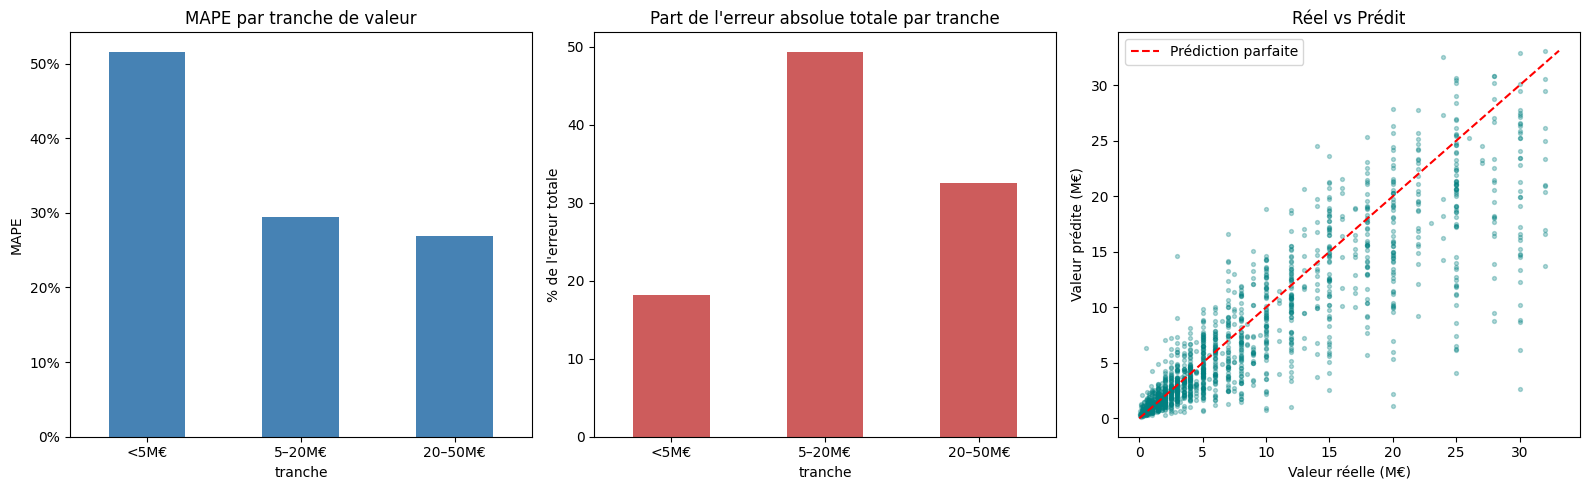

In [144]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — MAPE par tranche
synthese["MAPE"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("MAPE par tranche de valeur")
axes[0].set_ylabel("MAPE")
axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# Plot 2 — % erreur totale par tranche
synthese["% erreur totale"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="none")
axes[1].set_title("Part de l'erreur absolue totale par tranche")
axes[1].set_ylabel("% de l'erreur totale")
axes[1].tick_params(axis="x", rotation=0)

# Plot 3 — Valeurs réelles vs prédites
sample = df_erreur.sample(min(2000, len(df_erreur)), random_state=RANDOM_STATE)
axes[2].scatter(sample["y_reel"] / 1e6, sample["y_pred"] / 1e6, alpha=0.3, s=8, color="teal")
lim = max(sample["y_reel"].max(), sample["y_pred"].max()) / 1e6
axes[2].plot([0, lim], [0, lim], "r--", lw=1.5, label="Prédiction parfaite")
axes[2].set_xlabel("Valeur réelle (M€)")
axes[2].set_ylabel("Valeur prédite (M€)")
axes[2].set_title("Réel vs Prédit")
axes[2].legend()

plt.tight_layout()
plt.show()

#### B5.9 : Feature importance (CatBoost)

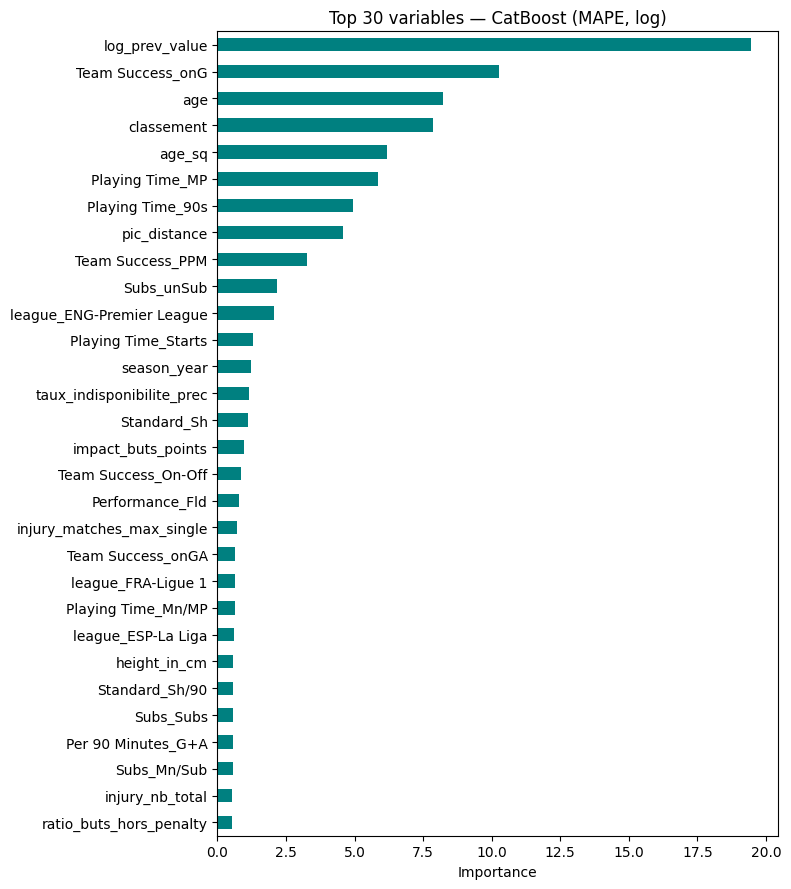


Top 30 :
log_prev_value               19.464575
Team Success_onG             10.249717
age                           8.221324
classement                    7.854715
age_sq                        6.190997
Playing Time_MP               5.862115
Playing Time_90s              4.930249
pic_distance                  4.582866
Team Success_PPM              3.248138
Subs_unSub                    2.173147
league_ENG-Premier League     2.065108
Playing Time_Starts           1.294146
season_year                   1.211962
taux_indisponibilite_prec     1.152929
Standard_Sh                   1.118785
impact_buts_points            0.982681
Team Success_On-Off           0.871355
Performance_Fld               0.799957
injury_matches_max_single     0.724286
Team Success_onGA             0.656998
league_FRA-Ligue 1            0.655992
Playing Time_Mn/MP            0.623299
league_ESP-La Liga            0.587608
height_in_cm                  0.575797
Standard_Sh/90                0.570300
Subs_Subs      

In [145]:
importances = pd.Series(
    cat_final.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.head(30).sort_values().plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 30 variables — CatBoost (MAPE, log)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 30 :")
print(importances.head(30).to_string())

### B6 : Réduction de dimensionnalité

**Ce qu'on teste :** réduire le nombre de features améliore-t-il les performances ?

**Ce qui varie ici :** le nombre et la sélection des features.  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test.

| Approche | Principe | Interprétabilité | Biais |
|---|---|---|---|
| **ACP 95%/99%/99.9%** | Composantes orthogonales classées par variance | Non | Non |
| **Sélection gain** top 50/75/100 | Features les plus importantes (XGBoost) | Oui | Haute cardinalité |
| **Permutation Importance** > 0/0.001/0.005 | Dégradation réelle si la feature est mélangée | Oui | Non biaisée |

#### B6.2 — Baseline de référence

On évalue d'abord le Stacking OOF **sans réduction** pour avoir un point de comparaison objectif. Toute approche qui fait moins bien que cette baseline n'apporte rien.

In [146]:
def rmse_log(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred,0,None))))

def evaluer_complet(label, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred)
    r2       = r2_score(y_true, y_pred)
    rl       = rmse_log(y_true, y_pred)
    n, p_    = len(y_true), 1
    return {"Label": label, "MAE": mae, "RMSE": rmse, "MAPE": mape,
            "R²": r2, "RMSE_log": rl}

def entrainer_stack(X_tr, y_tr_log, X_val_, y_val_log_, X_te, y_val, w=None):
    """Entraîne XGB+LGBM+CAT + stacking OOF. Renvoie preds_val, preds_test."""
    xgb = XGBRegressor(n_estimators=1000, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        tree_method="hist", enable_categorical=True,
                        objective="reg:squarederror",
                        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    lgbm = LGBMRegressor(n_estimators=1000, num_leaves=63, max_depth=6,
                          learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                          random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    cat  = CatBoostRegressor(iterations=1500, depth=6, learning_rate=0.05,
                              l2_leaf_reg=3, bootstrap_type="Bernoulli",
                              random_state=RANDOM_STATE, verbose=0)
    modeles = {"XGBoost": xgb, "LightGBM": lgbm, "CatBoost": cat}
    kw = {"sample_weight": w} if w is not None else {}

    # OOF
    oof = {}
    for nom, m in modeles.items():
        oof[nom] = cross_val_predict(m, X_tr, y_tr_log, cv=5, n_jobs=-1)

    # Ré-entraînement
    for nom, m in modeles.items():
        if isinstance(m, CatBoostRegressor):
            m.fit(X_tr, y_tr_log, eval_set=(X_val_, y_val_log_), verbose=False, **kw)
        else:
            m.fit(X_tr, y_tr_log, **kw)

    X_meta_tr  = pd.DataFrame(oof)
    X_meta_val = pd.DataFrame({n: m.predict(X_val_) for n,m in modeles.items()})
    X_meta_te  = pd.DataFrame({n: m.predict(X_te)  for n,m in modeles.items()})

    meta = LinearRegression(positive=True)
    meta.fit(X_meta_tr, y_tr_log)

    return (np.expm1(meta.predict(X_meta_val)),
            np.expm1(meta.predict(X_meta_te)),
            modeles)

print("Entraînement baseline (sans réduction)...")
pred_val_base, pred_test_base, modeles_base = entrainer_stack(
    X_train, y_train_log, X_val, y_val_log, X_test, y_val, w=sample_weights_train)

res_base = evaluer_complet("Sans réduction", y_test, pred_test_base)
print(f"  MAPE : {res_base['MAPE']:.2%} | R² : {res_base['R²']:.4f} | RMSE_log : {res_base['RMSE_log']:.4f}")
resultats_comparaison = [res_base]

Entraînement baseline (sans réduction)...
  MAPE : 41.17% | R² : 0.7410 | RMSE_log : 0.5483


#### B6.2 : ACP (Analyse en Composantes Principales)

**Étapes :**
1. Imputation des NaN résiduels par la médiane (nécessaire avant StandardScaler)
2. Standardisation
3. Calcul de la variance expliquée cumulée
4. Test de 3 seuils : 95%, 99%, 99.9% de variance conservée

NaN restants — train: 0 | val: 0 | test: 0
Dimensions originales : 145 features
Composantes pour 95%  de variance : 80
Composantes pour 99%  de variance : 105
Composantes pour 99.9% de variance : 121


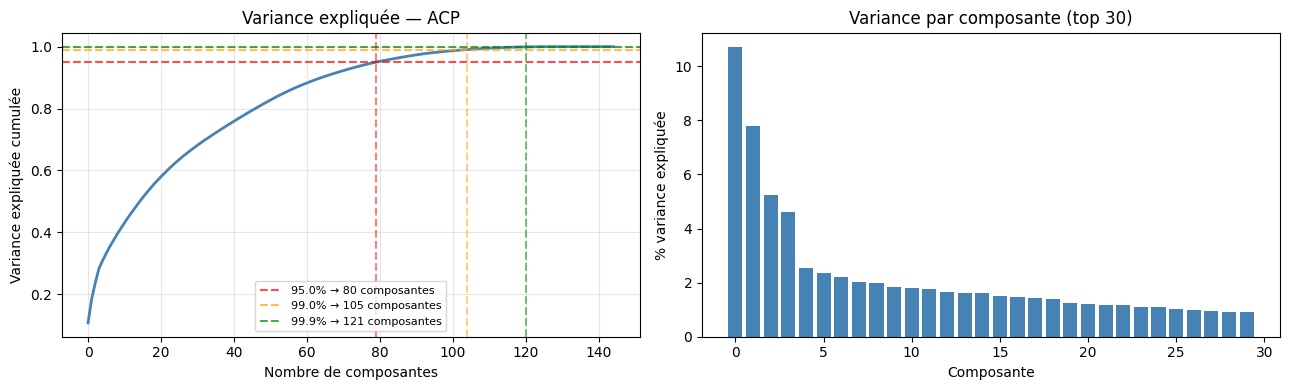

In [147]:
# Imputation des NaN résiduels (médiane par colonne, apprise sur le train)
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns,  index=X_test.index)

print(f"NaN restants — train: {X_train_imp.isnull().sum().sum()} | val: {X_val_imp.isnull().sum().sum()} | test: {X_test_imp.isnull().sum().sum()}")

# Standardisation obligatoire avant ACP
scaler_acp = StandardScaler()
X_train_scaled = scaler_acp.fit_transform(X_train_imp)
X_val_scaled   = scaler_acp.transform(X_val_imp)
X_test_scaled  = scaler_acp.transform(X_test_imp)

# ACP — on cherche le nombre de composantes pour 95% de variance expliquée
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

variance_cumul = np.cumsum(pca_full.explained_variance_ratio_)
n_95  = np.argmax(variance_cumul >= 0.95) + 1
n_99  = np.argmax(variance_cumul >= 0.99) + 1
n_999 = np.argmax(variance_cumul >= 0.999) + 1

print(f"Dimensions originales : {X_train.shape[1]} features")
print(f"Composantes pour 95%  de variance : {n_95}")
print(f"Composantes pour 99%  de variance : {n_99}")
print(f"Composantes pour 99.9% de variance : {n_999}")

# Visualisation de la variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(variance_cumul, lw=2, color="steelblue")
for thresh, n, color in [(0.95, n_95, "red"), (0.99, n_99, "orange"), (0.999, n_999, "green")]:
    axes[0].axhline(thresh, linestyle="--", color=color, alpha=0.7,
                     label=f"{thresh:.1%} → {n} composantes")
    axes[0].axvline(n-1, linestyle="--", color=color, alpha=0.5)
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("Variance expliquée cumulée")
axes[0].set_title("Variance expliquée — ACP")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Variance par composante (top 30)
axes[1].bar(range(30), pca_full.explained_variance_ratio_[:30]*100,
             color="steelblue", edgecolor="none")
axes[1].set_xlabel("Composante")
axes[1].set_ylabel("% variance expliquée")
axes[1].set_title("Variance par composante (top 30)")
plt.tight_layout()
plt.show()

In [148]:
# Test avec 3 seuils de variance : 95%, 99%, 99.9%
for seuil, n_comp, label_acp in [
    (0.95,  n_95,  "ACP 95%"),
    (0.99,  n_99,  "ACP 99%"),
    (0.999, n_999, "ACP 99.9%"),
]:
    print(f"\n--- {label_acp} ({n_comp} composantes) ---")
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xtr_pca  = pca.fit_transform(X_train_scaled)
    Xval_pca = pca.transform(X_val_scaled)
    Xte_pca  = pca.transform(X_test_scaled)

    # Convertir en DataFrame pour compatibilité (les arbres n'ont pas besoin de noms)
    Xtr_pca  = pd.DataFrame(Xtr_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])
    Xval_pca = pd.DataFrame(Xval_pca, columns=[f"PC{i+1}" for i in range(n_comp)])
    Xte_pca  = pd.DataFrame(Xte_pca,  columns=[f"PC{i+1}" for i in range(n_comp)])

    # y_val_log doit être réindexé
    y_val_log_arr = y_val_log.values

    pred_val_acp, pred_te_acp, _ = entrainer_stack(
        Xtr_pca, y_train_log.values, Xval_pca,
        pd.Series(y_val_log_arr), Xte_pca, y_val,
        w=sample_weights_train.values
    )
    res = evaluer_complet(label_acp, y_test.values, pred_te_acp)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- ACP 95% (80 composantes) ---
  MAPE : 53.20% | R² : 0.6555 | RMSE_log : 0.6095

--- ACP 99% (105 composantes) ---
  MAPE : 52.06% | R² : 0.6243 | RMSE_log : 0.6161

--- ACP 99.9% (121 composantes) ---
  MAPE : 51.96% | R² : 0.6295 | RMSE_log : 0.6197


#### B6.3 : Sélection par importance XGBoost (gain)

On entraîne un XGBoost rapide pour extraire l'importance par gain de chaque feature, puis on garde les top N les plus importantes.

⚠️ **Attention :** l'importance par gain est biaisée : elle tend à sur-estimer les features à haute cardinalité (comme les variables continues) par rapport aux variables binaires.

Features total : 145
Features avec importance > 0   : 135
Features avec importance > 0.01 (1%) : 15
Features avec importance > 0.005 (0.5%) : 30
Top 20 features :
Team Success_onG             0.169456
log_prev_value               0.150388
league_ENG-Premier League    0.039050
Standard_Sh                  0.035943
classement                   0.033730
impact_buts_points           0.033659
age                          0.029165
pic_age                      0.026300
league_FRA-Ligue 1           0.016834
injury_matches_max_single    0.014173
taux_indisponibilite_prec    0.013683
confederation_CONMEBOL       0.013085
Playing Time_MP              0.012498
Team Success_PPM             0.010796
Standard_SoT                 0.010435
Subs_unSub                   0.009362
injury_musculaire_nb_m       0.009317
injury_nb_total              0.009231
league_ESP-La Liga           0.007700
Playing Time_90s             0.007169


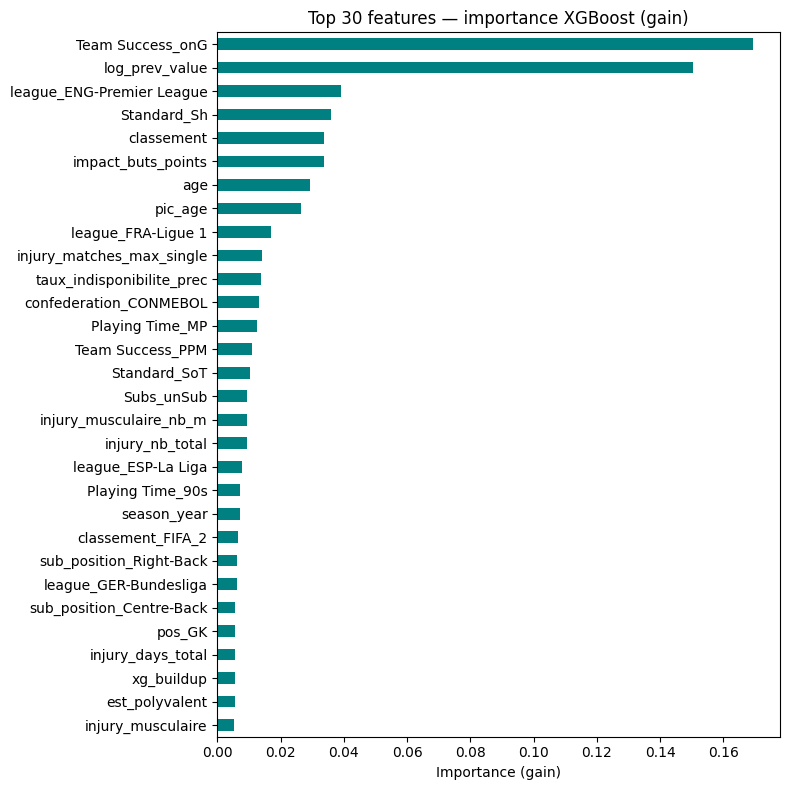

In [149]:
# Entraîner un XGBoost rapide pour obtenir les importances
selector_model = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    tree_method="hist", enable_categorical=True,
    objective="reg:squarederror",
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
selector_model.fit(X_train, y_train_log, sample_weight=sample_weights_train)

importances = pd.Series(selector_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(f"Features total : {len(importances)}")
print(f"Features avec importance > 0   : {(importances > 0).sum()}")
print(f"Features avec importance > 0.01 (1%) : {(importances > 0.01).sum()}")
print(f"Features avec importance > 0.005 (0.5%) : {(importances > 0.005).sum()}")
print(f"Top 20 features :")
print(importances.head(20).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(30).sort_values().plot(kind="barh", ax=ax, color="teal", edgecolor="none")
ax.set_title("Top 30 features — importance XGBoost (gain)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

In [150]:
# Tester plusieurs seuils de sélection
for seuil_n, label_sfm in [(50, "SFM top 50"), (75, "SFM top 75"), (100, "SFM top 100")]:
    features_sel = importances.head(seuil_n).index.tolist()
    print(f"\n--- {label_sfm} ({len(features_sel)} features) ---")

    pred_val_sfm, pred_te_sfm, _ = entrainer_stack(
        X_train[features_sel], y_train_log, X_val[features_sel], y_val_log,
        X_test[features_sel], y_val, w=sample_weights_train
    )
    res = evaluer_complet(label_sfm, y_test, pred_te_sfm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- SFM top 50 (50 features) ---
  MAPE : 40.44% | R² : 0.7357 | RMSE_log : 0.5478

--- SFM top 75 (75 features) ---
  MAPE : 41.71% | R² : 0.7409 | RMSE_log : 0.5508

--- SFM top 100 (100 features) ---
  MAPE : 41.02% | R² : 0.7432 | RMSE_log : 0.5480


#### B6.4 : Permutation importance

La permutation importance mélange aléatoirement chaque feature une par une sur le jeu de **validation** (pas le train, mémorisé par les arbres) et mesure la dégradation de performance. Elle est **non biaisée** et capture l'impact réel sur les prédictions.

Calcul permutation importance (peut prendre 2-3 minutes)...

Features avec permutation importance > 0   : 90
Features avec permutation importance < 0   : 40 (mélanger améliore → bruit)

Top 30 permutation importance :
log_prev_value                   0.390639
age                              0.381906
Team Success_onG                 0.255507
classement                       0.078066
league_ENG-Premier League        0.058999
Team Success_onGA                0.033720
Subs_unSub                       0.011838
Team Success_PPM                 0.011121
contribution_offensive_equipe    0.010988
Playing Time_MP                  0.010925
league_FRA-Ligue 1               0.010115
Playing Time_Starts              0.008535
Standard_Sh                      0.008341
impact_buts_points               0.006041
Playing Time_Mn/MP               0.005487
Team Success_On-Off              0.005303
Performance_Fls                  0.004763
Playing Time_90s                 0.003911
Performance_Fld           

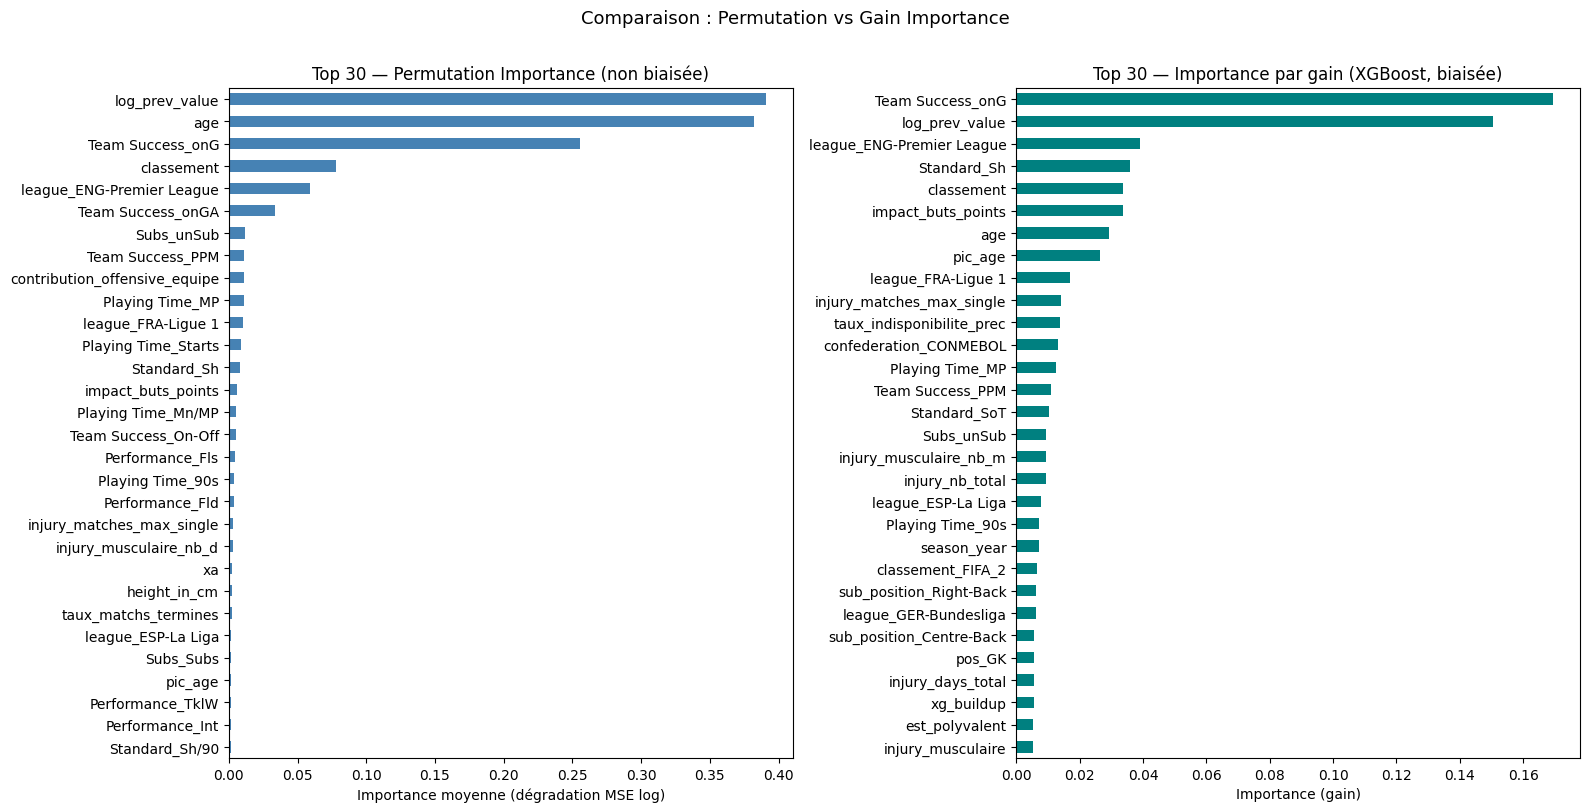

In [151]:
# Calculer la permutation importance sur le jeu de VALIDATION
# (sur le train on surestimerait l'importance car les arbres ont mémorisé le train)
print("Calcul permutation importance (peut prendre 2-3 minutes)...")

perm_result = permutation_importance(
    selector_model, X_val, y_val_log,
    n_repeats=10,           # 10 permutations par feature → estimation stable
    random_state=RANDOM_STATE,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

perm_imp = pd.Series(perm_result.importances_mean, index=X_train.columns)
perm_std = pd.Series(perm_result.importances_std,  index=X_train.columns)
perm_imp = perm_imp.sort_values(ascending=False)

print(f"\nFeatures avec permutation importance > 0   : {(perm_imp > 0).sum()}")
print(f"Features avec permutation importance < 0   : {(perm_imp < 0).sum()} (mélanger améliore → bruit)")
print(f"\nTop 30 permutation importance :")
print(perm_imp.head(30).to_string())

# Comparaison gain vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

perm_imp.head(30).sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="none")
axes[0].set_title("Top 30 — Permutation Importance (non biaisée)")
axes[0].set_xlabel("Importance moyenne (dégradation MSE log)")

importances.head(30).sort_values().plot(kind="barh", ax=axes[1], color="teal", edgecolor="none")
axes[1].set_title("Top 30 — Importance par gain (XGBoost, biaisée)")
axes[1].set_xlabel("Importance (gain)")

plt.suptitle("Comparaison : Permutation vs Gain Importance", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [152]:
# Sélection sur la base de la permutation importance
# On garde uniquement les features avec importance > 0 (mélanger les dégrade vraiment)
for seuil_perm, label_perm in [
    (0,    "Perm > 0  (toutes utiles)"),
    (0.001,"Perm > 0.001"),
    (0.005,"Perm > 0.005"),
]:
    features_perm = perm_imp[perm_imp > seuil_perm].index.tolist()
    if len(features_perm) < 5:
        print(f"Trop peu de features ({len(features_perm)}) pour seuil {seuil_perm}, skip")
        continue
    print(f"\n--- {label_perm} ({len(features_perm)} features) ---")

    pred_val_perm, pred_te_perm, _ = entrainer_stack(
        X_train[features_perm], y_train_log, X_val[features_perm], y_val_log,
        X_test[features_perm], y_val, w=sample_weights_train.values
    )
    res = evaluer_complet(label_perm, y_test, pred_te_perm)
    print(f"  MAPE : {res['MAPE']:.2%} | R² : {res['R²']:.4f} | RMSE_log : {res['RMSE_log']:.4f}")
    resultats_comparaison.append(res)


--- Perm > 0  (toutes utiles) (90 features) ---
  MAPE : 42.18% | R² : 0.7515 | RMSE_log : 0.5434

--- Perm > 0.001 (32 features) ---
  MAPE : 42.30% | R² : 0.7422 | RMSE_log : 0.5452

--- Perm > 0.005 (16 features) ---
  MAPE : 43.41% | R² : 0.7371 | RMSE_log : 0.5526


#### B6.5 : Tableau comparatif final

=== COMPARAISON FINALE (Test) ===
                                      MAE            RMSE    MAPE      R² RMSE_log
Label                                                                             
Sans réduction                2,540,646 €     4,223,785 €  41.17%  0.7410   0.5483
ACP 95%                       2,983,902 €     4,870,869 €  53.20%  0.6555   0.6095
ACP 99%                       3,097,243 €     5,086,521 €  52.06%  0.6243   0.6161
ACP 99.9%                     3,084,516 €     5,051,638 €  51.96%  0.6295   0.6197
SFM top 50                    2,540,025 €     4,266,255 €  40.44%  0.7357   0.5478
SFM top 75                    2,526,957 €     4,224,234 €  41.71%  0.7409   0.5508
SFM top 100                   2,515,904 €     4,205,756 €  41.02%  0.7432   0.5480
Perm > 0  (toutes utiles)     2,488,603 €     4,136,780 €  42.18%  0.7515   0.5434
Perm > 0.001                  2,512,577 €     4,213,539 €  42.30%  0.7422   0.5452
Perm > 0.005                  2,539,779 €     4,255,2

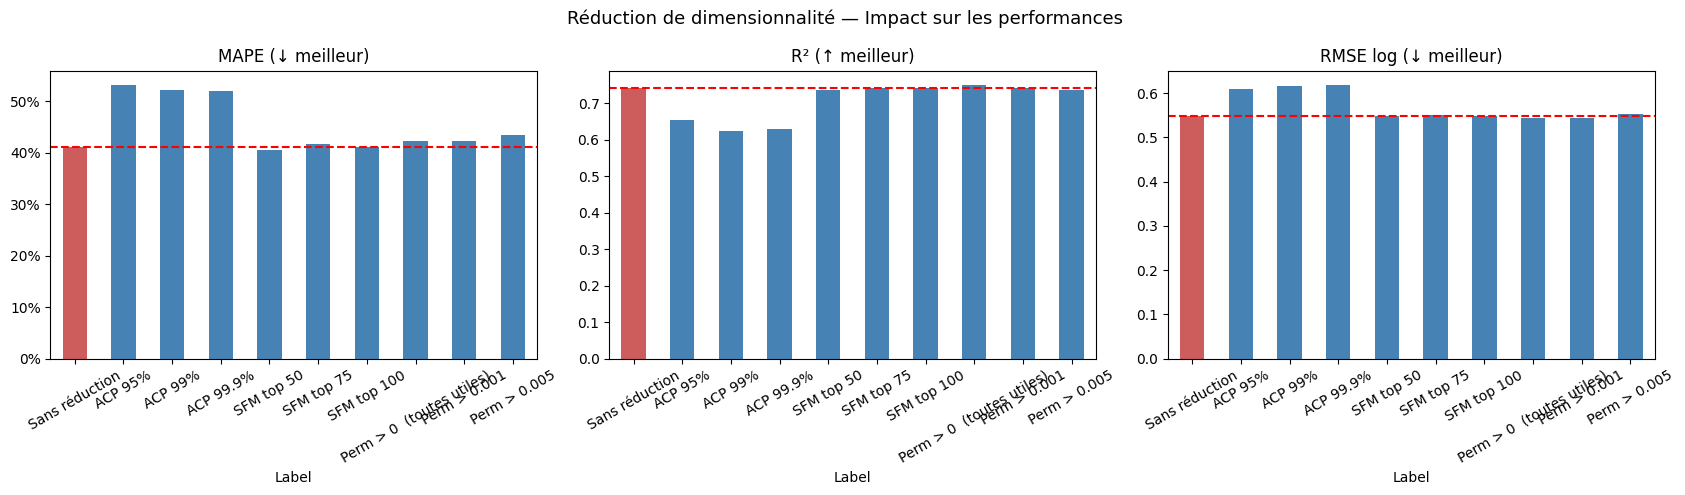

In [153]:
df_comp = pd.DataFrame(resultats_comparaison).set_index("Label")
df_comp["MAE"]  = df_comp["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["RMSE"] = df_comp["RMSE"].apply(lambda x: f"{x:>12,.0f} €")
df_comp["MAPE"] = df_comp["MAPE"].apply(lambda x: f"{x:.2%}")
df_comp["R²"]   = df_comp["R²"].apply(lambda x: f"{x:.4f}")
df_comp["RMSE_log"] = df_comp["RMSE_log"].apply(lambda x: f"{x:.4f}")

print("=== COMPARAISON FINALE (Test) ===")
print(df_comp.to_string())

# Visualisation
df_viz = pd.DataFrame(resultats_comparaison)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = ["steelblue" if "Sans" not in l else "indianred" for l in df_viz["Label"]]

df_viz.set_index("Label")["MAPE"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="none")
axes[0].set_title("MAPE (↓ meilleur)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0%}"))
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(res_base["MAPE"], color="red", lw=1.5, linestyle="--", label="baseline")

df_viz.set_index("Label")["R²"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="none")
axes[1].set_title("R² (↑ meilleur)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(res_base["R²"], color="red", lw=1.5, linestyle="--")

df_viz.set_index("Label")["RMSE_log"].plot(kind="bar", ax=axes[2], color=colors, edgecolor="none")
axes[2].set_title("RMSE log (↓ meilleur)")
axes[2].tick_params(axis="x", rotation=30)
axes[2].axhline(res_base["RMSE_log"], color="red", lw=1.5, linestyle="--")

plt.suptitle("Réduction de dimensionnalité — Impact sur les performances", fontsize=13)
plt.tight_layout()
plt.show()

### B7 : Modèles séparés : Gardiens / Joueurs de champ

**Ce qu'on teste :** spécialiser un modèle par position améliore-t-il les performances ?

**Ce qui varie ici :** la population d'entraînement (GK ou joueurs de champ).  
**Ce qui reste fixe :** pipeline Bloc A, même architecture (Stacking OOF, log1p), même test.

**Hypothèse :** les gardiens ont des stats fondamentalement différentes (saves, CS%, SoTA...) des joueurs de champ (buts, xG, dribbles...). Un modèle unique fait des compromis.

#### B7.1 : Séparation des populations

In [154]:
mask_train_gk = X_train["pos_GK"] == 1
mask_val_gk   = X_val["pos_GK"] == 1
mask_test_gk  = X_test["pos_GK"] == 1

X_train_gk, y_train_gk = X_train[mask_train_gk], y_train[mask_train_gk]
X_val_gk,   y_val_gk   = X_val[mask_val_gk],     y_val[mask_val_gk]
X_test_gk,  y_test_gk  = X_test[mask_test_gk],   y_test[mask_test_gk]

X_train_champ, y_train_champ = X_train[~mask_train_gk], y_train[~mask_train_gk]
X_val_champ,   y_val_champ   = X_val[~mask_val_gk],     y_val[~mask_val_gk]
X_test_champ,  y_test_champ  = X_test[~mask_test_gk],   y_test[~mask_test_gk]

print(f"Gardiens         : {len(X_train_gk):>5} train | {len(X_val_gk):>4} val | {len(X_test_gk):>4} test")
print(f"Joueurs de champ : {len(X_train_champ):>5} train | {len(X_val_champ):>4} val | {len(X_test_champ):>4} test")

colonnes_position = ["pos_DF", "pos_FW", "pos_GK", "pos_MF"]

X_train_gk_feat    = X_train_gk.drop(columns=colonnes_position)
X_val_gk_feat      = X_val_gk.drop(columns=colonnes_position)
X_test_gk_feat     = X_test_gk.drop(columns=colonnes_position)

X_train_champ_feat = X_train_champ.drop(columns=colonnes_position)
X_val_champ_feat   = X_val_champ.drop(columns=colonnes_position)
X_test_champ_feat  = X_test_champ.drop(columns=colonnes_position)

Gardiens         :   544 train |  172 val |  130 test
Joueurs de champ :  6290 train | 2035 val | 1449 test


#### B7.2 : Tuning par groupe

On utilise `N_TRIALS_SPLIT = 50` (au lieu de 75) car les sous-populations sont plus petites et TPE converge plus vite sur des espaces de recherche réduits.

In [155]:
N_TRIALS_SPLIT = 20   # sous-populations plus petites → moins d'essais nécessaires

FIXED_PARAMS = {
    RandomForestRegressor: {"random_state": RANDOM_STATE, "n_jobs": -1},
    ExtraTreesRegressor:   {"random_state": RANDOM_STATE, "n_jobs": -1},
    XGBRegressor:          {"tree_method": "hist", "enable_categorical": True,
                            "objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0, "verbose": False},
    LGBMRegressor:         {"random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1},
}

def espace_forest(trial):
    return {
        "n_estimators":      trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":         trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
    }

def espace_xgb(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def espace_lgbm(trial):
    return {
        "n_estimators":     trial.suggest_int("n_estimators", 300, 3000, step=200),
        "num_leaves":       trial.suggest_int("num_leaves", 15, 255),
        "max_depth":        trial.suggest_int("max_depth", 3, 15),
        "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
    }

def tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials):
    fixed = FIXED_PARAMS[model_class]
    def objective(trial):
        params = {**espace_fn(trial), **fixed}
        model = model_class(**params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_ev)
        return np.sqrt(mean_squared_error(y_ev, preds))
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

modeles_a_tuner = {
    "Random Forest": (RandomForestRegressor, espace_forest),
    "Extra Trees":   (ExtraTreesRegressor,   espace_forest),
    "XGBoost":       (XGBRegressor,          espace_xgb),
    "LightGBM":      (LGBMRegressor,         espace_lgbm),
}

In [156]:
groupes = {
    "Gardiens":        (X_train_gk_feat,    y_train_gk,    X_val_gk_feat,    y_val_gk),
    "Joueurs de champ":(X_train_champ_feat, y_train_champ, X_val_champ_feat, y_val_champ),
}

tuning_par_groupe = {}

for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    tuning_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, espace_fn) in modeles_a_tuner.items():
        print(f"\n=== Tuning {nom_modele} — {nom_groupe} ===")
        study = tuner_modele(model_class, espace_fn, X_tr, y_tr, X_ev, y_ev, n_trials=N_TRIALS_SPLIT)
        tuning_par_groupe[nom_groupe][nom_modele] = study
        print(f"Meilleur RMSE : {study.best_value:,.0f} € | Params : {study.best_params}")


=== Tuning Random Forest — Gardiens ===


Best trial: 16. Best value: 4.43534e+06: 100%|██████████| 20/20 [00:25<00:00,  1.26s/it]


Meilleur RMSE : 4,435,335 € | Params : {'n_estimators': 600, 'max_depth': 22, 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 0.8}

=== Tuning Extra Trees — Gardiens ===


Best trial: 13. Best value: 4.36436e+06: 100%|██████████| 20/20 [00:15<00:00,  1.32it/s]


Meilleur RMSE : 4,364,357 € | Params : {'n_estimators': 500, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 0.8}

=== Tuning XGBoost — Gardiens ===


...

Meilleur RMSE : 3,916,550 € | Params : {'n_estimators': 400, 'max_depth': 27, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 1.0}

=== Tuning XGBoost — Joueurs de champ ===


Best trial: 16. Best value: 3.72751e+06: 100%|██████████| 20/20 [05:04<00:00, 15.24s/it]


Meilleur RMSE : 3,727,513 € | Params : {'n_estimators': 1900, 'max_depth': 8, 'learning_rate': 0.009069793582172334, 'subsample': 0.9051335653488248, 'colsample_bytree': 0.6353734862295112, 'min_child_weight': 8.709012755018751, 'reg_alpha': 0.006581381460674812, 'reg_lambda': 1.54315397143009}

=== Tuning LightGBM — Joueurs de champ ===


Best trial: 5. Best value: 3.71614e+06: 100%|██████████| 20/20 [02:33<00:00,  7.68s/it]

Meilleur RMSE : 3,716,139 € | Params : {'n_estimators': 2900, 'num_leaves': 227, 'max_depth': 7, 'learning_rate': 0.009371623276246296, 'subsample': 0.8133748652604686, 'colsample_bytree': 0.5164693597090454, 'reg_alpha': 3.573390196397759, 'reg_lambda': 0.0020518537962070666}


#### B7.3 : Entraînement des modèles spécifiques

Les modèles sont construits **une seule fois ici** et gelés pour la comparaison. On évite ainsi tout re-fit accidentel entre les étapes de comparaison validation et test.

In [157]:
# Construction des modèles finaux, spécifiques à chaque groupe
# On les construit ici une seule fois et on les garde gelés pour la comparaison

modeles_finaux_par_groupe = {}
for nom_groupe in groupes:
    modeles_finaux_par_groupe[nom_groupe] = {}
    for nom_modele, (model_class, _) in modeles_a_tuner.items():
        study = tuning_par_groupe[nom_groupe][nom_modele]
        modeles_finaux_par_groupe[nom_groupe][nom_modele] = model_class(
            **study.best_params, **FIXED_PARAMS[model_class]
        )

# Pré-entraînement des modèles spécifiques sur leur groupe respectif

modeles_groupe_entraines = {}
for nom_groupe, (X_tr, y_tr, X_ev, y_ev) in groupes.items():
    modeles_groupe_entraines[nom_groupe] = {}
    for nom_modele, modele in modeles_finaux_par_groupe[nom_groupe].items():
        modele.fit(X_tr, y_tr)
        modeles_groupe_entraines[nom_groupe][nom_modele] = modele
        print(f"  {nom_groupe} / {nom_modele} : entraîné")

  Gardiens / Random Forest : entraîné
  Gardiens / Extra Trees : entraîné
  Gardiens / XGBoost : entraîné
  Gardiens / LightGBM : entraîné
  Joueurs de champ / Random Forest : entraîné
  Joueurs de champ / Extra Trees : entraîné
  Joueurs de champ / XGBoost : entraîné
  Joueurs de champ / LightGBM : entraîné


#### B7.4 : Comparaison modèle global vs modèle spécifique (validation)

On compare, sur chaque sous-groupe, le modèle global entraîné sur tout le train vs le modèle spécifique entraîné uniquement sur ce sous-groupe.

In [158]:
# Comparaison : modèle global vs modèle spécifique (validation)
sous_groupes_val = {
    "Gardiens":         (X_val_gk,    y_val_gk,    X_val_gk_feat),
    "Joueurs de champ": (X_val_champ, y_val_champ, X_val_champ_feat),
}

comparaison_groupes = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_val.items():
    for nom_modele in modeles_a_tuner:
        # Modèle global
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        # Modèle spécifique
        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes.append({
            "Groupe":          nom_groupe,
            "Modèle":          nom_modele,
            "MAE global":      mae_global,
            "R² global":       r2_global,
            "MAE spécifique":  mae_groupe,
            "R² spécifique":   r2_groupe,
            "Gain MAE":        mae_global - mae_groupe,
        })

df_comparaison_groupes = pd.DataFrame(comparaison_groupes)
print("CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes.to_string(index=False))

CLASSEMENT (Validation) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 2.455416e+06   0.683383    2.593628e+06       0.630843 -138211.594073
        Gardiens   Extra Trees 2.194776e+06   0.732712    2.519103e+06       0.642564 -324326.418561
        Gardiens       XGBoost 2.173569e+06   0.751469    2.356589e+06       0.696809 -183020.149846
        Gardiens      LightGBM 2.199774e+06   0.739258    2.535022e+06       0.663574 -335247.455884
Joueurs de champ Random Forest 2.617499e+06   0.690261    2.571473e+06       0.728780   46026.082160
Joueurs de champ   Extra Trees 2.474738e+06   0.727810    2.480945e+06       0.736016   -6207.552310
Joueurs de champ       XGBoost 2.558078e+06   0.709510    2.356369e+06       0.760884  201708.891254
Joueurs de champ      LightGBM 2.577230e+06   0.708446    2.391300e+06       0.762341  185930.467022


#### B7.5 : Évaluation finale sur le test

In [159]:
sous_groupes_test = {
    "Gardiens":         (X_test_gk,    y_test_gk,    X_test_gk_feat),
    "Joueurs de champ": (X_test_champ, y_test_champ, X_test_champ_feat),
}

comparaison_groupes_test = []
for nom_groupe, (X_ev, y_ev, X_ev_feat) in sous_groupes_test.items():
    for nom_modele in modeles_a_tuner:
        modele_global = modeles_tuned[nom_modele]
        preds_global  = modele_global.predict(X_ev)
        mae_global    = mean_absolute_error(y_ev, preds_global)
        r2_global     = r2_score(y_ev, preds_global)

        modele_groupe = modeles_groupe_entraines[nom_groupe][nom_modele]
        preds_groupe  = modele_groupe.predict(X_ev_feat)
        mae_groupe    = mean_absolute_error(y_ev, preds_groupe)
        r2_groupe     = r2_score(y_ev, preds_groupe)

        comparaison_groupes_test.append({
            "Groupe":         nom_groupe,
            "Modèle":         nom_modele,
            "MAE global":     mae_global,
            "R² global":      r2_global,
            "MAE spécifique": mae_groupe,
            "R² spécifique":  r2_groupe,
            "Gain MAE":       mae_global - mae_groupe,
        })

df_comparaison_groupes_test = pd.DataFrame(comparaison_groupes_test)
print("CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe")
print(df_comparaison_groupes_test.to_string(index=False))

CLASSEMENT FINAL (Test) — modèle global vs modèle spécifique par groupe
          Groupe        Modèle   MAE global  R² global  MAE spécifique  R² spécifique       Gain MAE
        Gardiens Random Forest 2.527307e+06   0.715855    2.951181e+06       0.645886 -423873.652981
        Gardiens   Extra Trees 2.383089e+06   0.748198    2.815847e+06       0.689410 -432757.918552
        Gardiens       XGBoost 2.524943e+06   0.731957    2.722334e+06       0.684005 -197390.397506
        Gardiens      LightGBM 2.535325e+06   0.733157    2.594229e+06       0.707910  -58903.404115
Joueurs de champ Random Forest 2.869307e+06   0.710230    2.797744e+06       0.740588   71562.956827
Joueurs de champ   Extra Trees 2.595919e+06   0.768689    2.688371e+06       0.754249  -92452.293536
Joueurs de champ       XGBoost 2.709631e+06   0.743038    2.528517e+06       0.776866  181113.996460
Joueurs de champ      LightGBM 2.759157e+06   0.736421    2.559154e+06       0.777965  200003.160025


## Partie C : Comparaison finale et sélection du meilleur modèle

Toutes les approches de la partie B comparées dans un **tableau unique**, sur le **même test**, avec le **même pipeline de base**. La comparaison est donc équitable.

**Métriques :**

| Métrique | Rôle | Sens |
|---|---|---|
| **MAPE** | Principale | Erreur relative en % — indépendante de l'échelle de valeur |
| **RMSE log** | Secondaire | Équivalent MAPE, stable numériquement |
| **R²** | Tertiaire | Variance expliquée — sensible aux erreurs sur les grandes valeurs |
| **MAE** | Contexte | Erreur absolue en € — dépendante de l'échelle |

### C.1 : Tableau comparatif

In [160]:
# Les parties B5 et B6 ont potentiellement écrasé y_test avec un dataset différent.
# On identifie le bon y_test en vérifiant la taille des prédictions principales.
taille_ref = len(pred_test_stack)   # B3 — Stacking OOF : référence fiable

# Si y_test a été écrasé, on le reconstruit depuis df_test
if len(y_test) != taille_ref:
    print(f"y_test ({len(y_test)}) ≠ taille référence ({taille_ref}) — reconstruction depuis df_test initial")
    y_test_c = df_test[colonne_cible] if colonne_cible in df_test.columns else df_test["market_value_in_eur"]
    y_test_c = y_test_c.dropna().reset_index(drop=True)
    # Vérification
    assert len(y_test_c) == taille_ref, f"Reconstruction échouée : {len(y_test_c)} ≠ {taille_ref}"
    print(f"y_test reconstruit : {len(y_test_c)} lignes")
else:
    y_test_c = y_test.reset_index(drop=True)
    print(f"y_test OK : {len(y_test_c)} lignes")

# Prédictions directes de même taille
def verif(name, arr):
    arr = np.array(arr, dtype=float)
    if len(arr) != taille_ref:
        print(f"    {name} ignoré : taille {len(arr)} ≠ {taille_ref}")
        return None
    return np.clip(arr, 0, None)

preds_directes = {
    "Blend Moyenne (B3 — Stacking initial)":                pred_test_moyenne,
    "Stacking OOF (B3 — Stacking initial)":                pred_test_stack,
    f"Stacking Tuné ({meilleure_transfo}) (B4 — Transfo)": pred_test_tuned_eur,
    "Stacking OOF sans outliers (B5)":                      np.expm1(meta.predict(X_meta_test)),
}

# Modèles à prédire (B1 — cible brute)
modeles_bruts = {
    "Random Forest (B1)": (modeles_tuned["Random Forest"],       X_test, False),
    "Extra Trees (B1)":   (modeles_tuned["Extra Trees"],         X_test, False),
    "XGBoost (B1)":       (modeles_tuned["XGBoost"],             X_test, False),
    "LightGBM (B1)":      (modeles_tuned["LightGBM"],            X_test, False),
    "CatBoost (B1)":      (modeles_tuned["CatBoost"],            X_test, False),
    "SVR (B1)":           (modeles_tuned_sans_nan["SVR"],        X_test_sans_nan, False),
    "ElasticNet (B1)":    (modeles_tuned_sans_nan["ElasticNet"], X_test_sans_nan, False),
}

# Modèles à prédire (B2 — cible log)
modeles_log = {
    "Random Forest log (B2)": (modeles_tuned_log["Random Forest (log)"],       X_test, True),
    "Extra Trees log (B2)":   (modeles_tuned_log["Extra Trees (log)"],         X_test, True),
    "XGBoost log (B2)":       (modeles_tuned_log["XGBoost (log)"],             X_test, True),
    "LightGBM log (B2)":      (modeles_tuned_log["LightGBM (log)"],            X_test, True),
    "CatBoost log (B2)":      (modeles_tuned_log["CatBoost (log)"],            X_test, True),
    "SVR log (B2)":           (modeles_tuned_log_sans_nan["SVR (log)"],        X_test_sans_nan, True),
    "ElasticNet log (B2)":    (modeles_tuned_log_sans_nan["ElasticNet (log)"], X_test_sans_nan, True),
}

# Prédictions B6 (réduction de dimensionnalité)
preds_b6 = {
    "Stacking + ACP (B6)":                  pred_te_acp,
    "Stacking + SelectFromModel (B6)":      pred_te_sfm,
    "Stacking + Permutation Importance (B6)": pred_te_perm,
}

# Calcul des métriques
results = []

def calcul_metriques(name, y_pred):
    y_pred = verif(name, y_pred)
    if y_pred is None: return
    mae      = mean_absolute_error(y_test_c, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test_c, y_pred))
    mape     = mean_absolute_percentage_error(y_test_c, y_pred)
    r2       = r2_score(y_test_c, y_pred)
    rmse_log = np.sqrt(mean_squared_error(np.log1p(y_test_c), np.log1p(y_pred)))
    n, p     = X_test.shape
    r2_adj   = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    results.append({"Modèle": name, "MAPE": mape, "RMSE_log": rmse_log,
                    "R²": r2, "R²_adj": r2_adj, "MAE": mae, "RMSE": rmse, "preds": y_pred})

for name, arr in preds_directes.items():
    calcul_metriques(name, arr)

for name, (modele, X_ev, is_log) in {**modeles_bruts, **modeles_log}.items():
    y_pred_raw = np.expm1(modele.predict(X_ev)) if is_log else modele.predict(X_ev)
    calcul_metriques(name, y_pred_raw)

for name, arr in preds_b6.items():
    calcul_metriques(name, arr)

# Tableau comparatif
df_all         = pd.DataFrame(results).set_index("Modèle").sort_values("MAPE")
df_recap_final = pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)

df_disp = df_all.drop(columns=["preds"]).copy()
df_disp["MAPE"]     = df_disp["MAPE"].apply(lambda x: f"{x:.2%}")
df_disp["RMSE_log"] = df_disp["RMSE_log"].apply(lambda x: f"{x:.4f}")
df_disp["R²"]       = df_disp["R²"].apply(lambda x: f"{x:.4f}")
df_disp["R²_adj"]   = df_disp["R²_adj"].apply(lambda x: f"{x:.4f}")
df_disp["MAE"]      = df_disp["MAE"].apply(lambda x: f"{x:>12,.0f} €")
df_disp["RMSE"]     = df_disp["RMSE"].apply(lambda x: f"{x:>12,.0f} €")

print("CLASSEMENT FINAL — Toutes approches (Test, trié par MAPE croissant)")
print(df_disp.to_string())

y_test OK : 1579 lignes
    Blend Moyenne (B3 — Stacking initial) ignoré : taille 1751 ≠ 1579
    Stacking Tuné (Rang normal) (B4 — Transfo) ignoré : taille 1751 ≠ 1579
    SVR (B1) ignoré : taille 1751 ≠ 1579
    ElasticNet (B1) ignoré : taille 1751 ≠ 1579
    SVR log (B2) ignoré : taille 1751 ≠ 1579
    ElasticNet log (B2) ignoré : taille 1751 ≠ 1579
CLASSEMENT FINAL — Toutes approches (Test, trié par MAPE croissant)
                                          MAPE RMSE_log      R²  R²_adj             MAE            RMSE
Modèle                                                                                                 
Stacking OOF (B3 — Stacking initial)    40.62%   0.5430  0.7505  0.7252     2,485,764 €     4,145,379 €
Stacking OOF sans outliers (B5)         40.62%   0.5430  0.7505  0.7252     2,485,764 €     4,145,379 €
Stacking + SelectFromModel (B6)         41.02%   0.5480  0.7432  0.7172     2,515,904 €     4,205,756 €
XGBoost log (B2)                        43.05%   0.5607  

### C.2 : Visualisation comparative

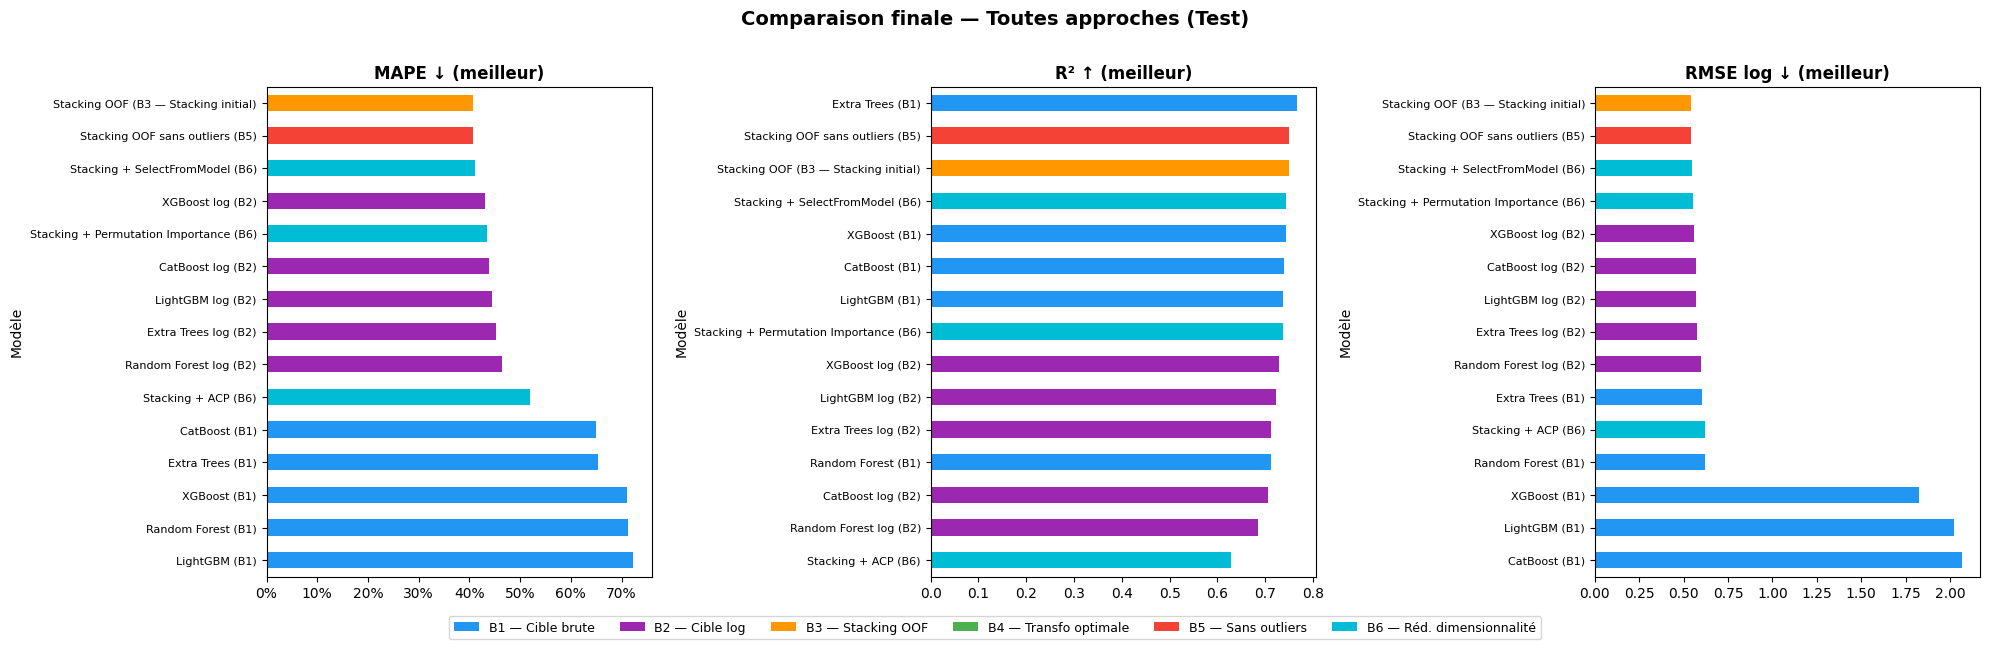

In [161]:
def get_color(lbl):
    if "B1" in lbl: return "#2196F3"
    if "B2" in lbl: return "#9C27B0"
    if "B3" in lbl: return "#FF9800"
    if "B4" in lbl: return "#4CAF50"
    if "B5" in lbl: return "#F44336"
    if "B6" in lbl: return "#00BCD4"
    return "#9E9E9E"

colors = [get_color(l) for l in df_all.index]

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, len(df_all) * 0.4)))
for ax, col, title, ascending in [
    (axes[0], "MAPE",     "MAPE ↓ (meilleur)",      True),
    (axes[1], "R²",       "R² ↑ (meilleur)",         False),
    (axes[2], "RMSE_log", "RMSE log ↓ (meilleur)",   True),
]:
    df_sorted = df_all[col].sort_values(ascending=ascending)
    colors_sorted = [get_color(l) for l in df_sorted.index]
    df_sorted.plot(kind="barh", ax=ax, color=colors_sorted, edgecolor="none")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=8)
    if col == "MAPE":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
legend = [
    Patch(facecolor="#2196F3", label="B1 — Cible brute"),
    Patch(facecolor="#9C27B0", label="B2 — Cible log"),
    Patch(facecolor="#FF9800", label="B3 — Stacking OOF"),
    Patch(facecolor="#4CAF50", label="B4 — Transfo optimale"),
    Patch(facecolor="#F44336", label="B5 — Sans outliers"),
    Patch(facecolor="#00BCD4", label="B6 — Réd. dimensionnalité"),
]
fig.legend(handles=legend, loc="lower center", ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("Comparaison finale — Toutes approches (Test)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### C.3 : Modèle retenu et analyse par tranche

In [162]:
champion_row   = df_recap_final.iloc[0]
champion_lbl   = champion_row["Modèle"]
preds_champion = champion_row["preds"]

print(f"MODÈLE RETENU : {champion_lbl}")
print(f"  MAPE     : {champion_row['MAPE']:.2%}")
print(f"  R²       : {champion_row['R²']:.4f}")
print(f"  MAE      : {champion_row['MAE']:>12,.0f} €")
print(f"  RMSE_log : {champion_row['RMSE_log']:.4f}")

MODÈLE RETENU : Stacking OOF (B3 — Stacking initial)
  MAPE     : 40.62%
  R²       : 0.7505
  MAE      :    2,485,764 €
  RMSE_log : 0.5430
